In [165]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Self
from dataclasses import dataclass
from typing import Dict, List, Tuple, Iterable

import math

In [166]:
# Wealth Levels:
wealth_req = [0] * 51
consume_req = [0] * 51
luxuries_req = [0] * 51
for level in range(51): # 0 to 50 inclusive
    wealth_req[level] = 2 ** (level * 0.3) - 1     # 2^0.3x - 1
    consume_req[level] = level * 0.1 + 0.02 * max(0, level - 4) * 2 ** (level * 0.3) # 0.02 * max(0, x - 4) * 2^0.3x + 0.1x
    luxuries_req[level] = 2 ** (0.25 * max(0, level - 4)) - max(1, math.log(level - 4)) if level > 4 else 0 # 2^0.25(x-4) - max(ln(x-4), 1)

# Gets a wealth level based off per capita wealth.
# Returns an integer from 0 to 50 inclusive.
def get_wealth_level(pop: float, wealth: float) -> int:
    if wealth == 0:
        return 0
    
    per_capita = wealth / pop
    for level in range(50):
        if per_capita < wealth_req[level+1]:
            return level
        
    return 50

# Gets a shortage modifier based off wealth level.
# Higher wealth levels decreases shortage impact on the pop. It also applies a buffer.
# Eg. At wealth level 50, shortages only apply at a 50% shortage or higher. The effects of the shortage are also 50% less.
def get_shortage_modifier(wealth_level: int, shortage: float) -> float:
    buffer = wealth_level / 100.0
    effective_shortage = shortage - buffer

    if effective_shortage <= 0:
        return 0.0

    modifier = effective_shortage * (1.0 - (wealth_level / 100.0))
    return modifier

def get_land_productivity(land: float, workers: float, base_productivity: float = 2.0, saturation: float = 1.0, exp: float = 1.0) -> float:
    if land <= 0.0 or workers <= 0.0:
        return 0.0

    land_per_worker = land / workers
    productivity = base_productivity * ((land_per_worker / (land_per_worker + saturation)) ** exp)

    return productivity

def get_wage_share(share_min: float = 0.05, share_max: float = 0.85, ) -> float:
    return share_min

# This returns how many commoners will work elite owned land at a given wage share. 
# This is important for determining how many workers are producing for the elite vs how many are producing for themselves.
def get_workers_at_wage_share(wage_share: float, land_elite: float, land_commoner: float, commoners: float, slaves: float, desperation: float = 0.1, saturation: float = 1.0, exp: float = 1.0) -> float:
    # numerator = (W**1/e) * L_e * (L_c + sat * C) - L_c * L_e - L_c * sat * S
    # denominator = sat * (L_c + (W**1/e) * L_e)
    # C_e = numerator / denominator
    if commoners <= 0.0 or land_elite <= 0.0:
        return 0.0
    
    # 90% cap
    wage_eff = min(wage_share, 0.9)
    w_root = wage_eff ** (1/exp)

    # Productivity driven model
    numerator = w_root * land_elite * (land_commoner + saturation * commoners) - land_commoner * ( land_elite + saturation * slaves )
    denominator = saturation * (land_commoner + w_root * land_elite)
    ce_econ = numerator / denominator if abs(denominator) > 1e-8 else 0.0
    ce_econ = max(0.0, min(ce_econ, commoners))
    
    # Desperation driven model
    if land_commoner <= 0.0:
        return ce_econ
    r = land_elite / land_commoner
    ce_final = ce_econ + desperation * r * wage_eff * (commoners - ce_econ)
    ce_final = max(0.0, min(ce_final, commoners))

    return ce_final

# Returns elite wealth output at a given wage share.
def get_elite_wealth_output(wage_share: float, land_elite: float, land_commoner: float, commoners: float, slaves: float, saturation: float = 1.0, exp: float = 1.0) -> float:
    workers = get_workers_at_wage_share(wage_share, land_elite, land_commoner, commoners, slaves, saturation, exp)
    productivity = get_land_productivity(land_elite, workers + slaves, saturation, exp)
    return (1 - wage_share) * (workers + slaves) * productivity

# Optimizes the wage share for the elite to maximize their wealth output (1-W) * (C_e + S) * productivity.
# Used on startup to find the best wage share for the elite given the initial conditions. 
# It does a coarse search followed by a fine search around the best value found in the coarse search.
def optimize_wage_share(land_elite: float, land_commoner: float, commoners: float, slaves: float, saturation: float = 1.0, exp: float = 1.0) -> Tuple[float, float]:
    best_share = 0.0
    best_output = 0.0

    # Coarse search from 0% to 100% in 10% increments
    for share in np.linspace(0.0, 1.0, num=11):
        output = get_elite_wealth_output(share, land_elite, land_commoner, commoners, slaves, saturation, exp)
        if output > best_output:
            best_output = output
            best_share = share
    
    # Fine search around the best share found in the coarse search, in 1% increments
    for share in np.linspace(max(0.0, best_share - 0.1), min(1.0, best_share + 0.1), num=21):
        output = get_elite_wealth_output(share, land_elite, land_commoner, commoners, slaves, saturation, exp)
        if output > best_output:
            best_output = output
            best_share = share

    return best_share, best_output

# Optimizes wage share for elites for a single step. Used in each step to adjust the wage share as conditions change.
# It moves wage share in 1% increments every step, but only in the direction that increases elite wealth output. This simulates elites adjusting wages to maximize their wealth.
def adjust_wage_share(current_share: float, land_elite: float, land_commoner: float, commoners: float, slaves: float = 0.0, delta: float = 0.01, saturation: float = 1.0, exp: float = 1.0) -> float:
    current_wealth = get_elite_wealth_output(current_share, land_elite, land_commoner, commoners, slaves, saturation, exp)
    more_share_wealth = get_elite_wealth_output(min(current_share + delta, 1.0), land_elite, land_commoner, commoners, slaves, saturation, exp)
    less_share_wealth = get_elite_wealth_output(max(current_share - delta, 0.0), land_elite, land_commoner, commoners, slaves, saturation, exp)

    if more_share_wealth > current_wealth:
        return min(current_share + delta, 1.0)
    if less_share_wealth > current_wealth:
        return max(current_share - delta, 0.0)
    
    return current_share # already at optimal share

def get_wage_share(workers_count: float, jobs_count: float, worker_owned_count: float, k: float = -8.0, d_crit: float = 1.0) -> float:
    if jobs_count <= 0.0:
        return 0.0
    
    pressure = (workers_count - 0.25 * worker_owned_count) / jobs_count if jobs_count > 0 else float('inf')
    wage_share_base = logistic_formula(pressure, k=k, x0=d_crit)
    wage_share = max(0.1, min(0.9, 0.75 * wage_share_base + 0.1)) # Ensure wage share is between 10% and 90%
    
    return wage_share

# This function calculates the job capacity based on a base capacity, a technology multiplier, and an exponent. 
# The technology multiplier represents how much technology has improved the productivity of labor, while the exponent determines how quickly capacity increases (or decreases) with technology.
# Typical sector method exponents:
# - Agriculture: 0.95
# - Extractive: 0.7
# - Heavy Industrial: 0.3
# - Light Industrial: 0.4
# - Urban services: 0.4
# - Infrastructure: 0.0
# Typical sector tech exponents:
# - Agriculture: -0.7
# - Extractive: -0.6
# - Heavy Industrial: -0.8
# - Light Industrial: -0.6
# - Urban services: -0.5
# - Infrastructure: 0.0
def get_job_capacity(base_capacity: float, method_applied: float = 0.0, method_exponent: float = 1.0, tech_applied: float = 0.0, tech_exponent: float = -1.0, other_factor: float = 1.0) -> float:
    if base_capacity <= 0.0:
        return 0.0
    return base_capacity * ((method_applied + 1.0) ** method_exponent) * ((tech_applied + 1.0) ** tech_exponent) * other_factor

def get_output_multiplier(base_prod: float, method_applied: float, tech_applied: float, other_factor: float = 1.0) -> float:
    return base_prod * (1.0 + method_applied) * (1.0 + tech_applied) * other_factor

# Logistic formula for smooth transitions
# x - input value
# k - steepness of the curve
# x0 - the x value of the sigmoid's midpoint
def logistic_formula(x: float, k: float = 1.0, x0: float = 0.0) -> float:
    return 1 / (1 + math.exp(-k * (x - x0)))

In [167]:
# for x in range(51):
    # print(f"Wealth Level: {x}, Wealth Req: {wealth_req[x]:.2f}, Consume Req: {consume_req[x]:.2f}, Luxuries Req: {luxuries_req[x]:.2f}")
print(get_workers_at_wage_share(0.1, land_elite=30, land_commoner=100,
                                commoners=200, slaves=0, desperation=0.0))
# → old behavior (probably ~60–80 depending on params)

print(get_workers_at_wage_share(0.2, land_elite=30, land_commoner=100,
                                commoners=200, slaves=0, desperation=0.4))
# → always a few extra even when land is abundant

0.0
4.8


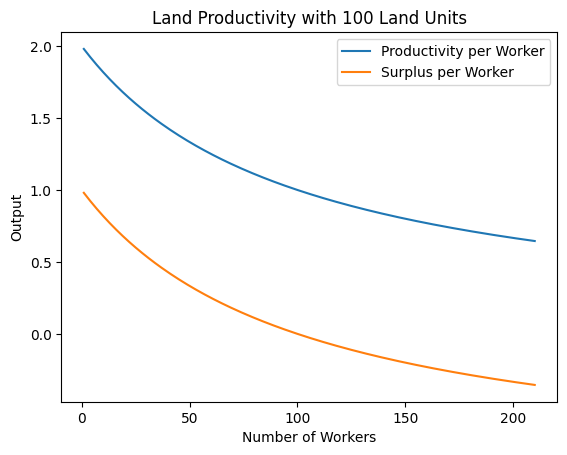

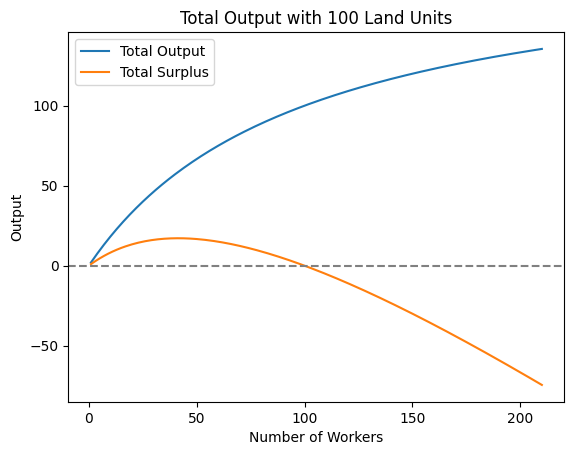

Surplus peaks at 41 workers with a surplus of 17.16
Zero crossing at 101 workers


C:\Users\white\AppData\Local\Temp\ipykernel_38336\2518650611.py:80: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


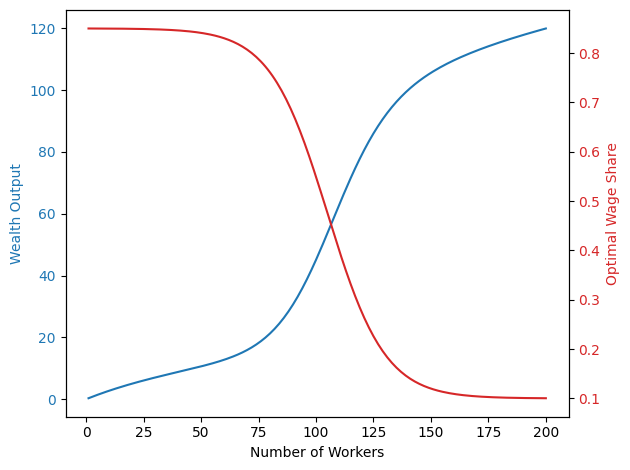

In [168]:
# Example usage and plotting
x_range = []
y_range_prod = []
y_range_rel_surplus = []
y_range_total = []
y_range_surplus = []

surplus_peak = 0
surplus_peak_value = 0
zero_crossing = 0
for x in range(210):
    land = 100
    workers = x + 1
    productivity = get_land_productivity(land, workers, base_productivity=2.0, saturation=1.0, exp=1.0)
    total_output = productivity * workers # Food per worker
    total_surplus = total_output - workers

    surplus_peak = workers if total_surplus > surplus_peak_value else surplus_peak
    surplus_peak_value = max(surplus_peak_value, total_surplus)
    zero_crossing = workers if total_surplus < 0 and zero_crossing == 0 else zero_crossing

    x_range.append(workers)
    y_range_prod.append(productivity)
    y_range_rel_surplus.append(total_surplus/workers)
    y_range_total.append(total_output)
    y_range_surplus.append(total_surplus)

x_range_elite_surplus = []
y_range_elite_optimal_wage = []
y_range_elite_wealth_output = []
for x in range(200):
    land_commoners = 20
    land_elites = 80
    commoners = x + 1

    optimal_wage = get_wage_share(commoners, jobs_count=land_elites+land_commoners, worker_owned_count=land_commoners, k=-8.0, d_crit=1.0)
    wealth_output = get_land_productivity(land_elites+land_commoners, commoners, base_productivity=2.0, saturation=1.0, exp=1.0) * (1 - optimal_wage) * commoners
    # optimal_wage, wealth_output = optimize_wage_share(land_elites, land_commoners, commoners, slaves=0, saturation=0.25, exp=3)
    x_range_elite_surplus.append(commoners)
    y_range_elite_optimal_wage.append(optimal_wage)
    y_range_elite_wealth_output.append(wealth_output)

plt.plot(x_range, y_range_prod, label="Productivity per Worker")
plt.plot(x_range, y_range_rel_surplus, label="Surplus per Worker")
plt.xlabel("Number of Workers")
plt.ylabel("Output")
plt.title("Land Productivity with 100 Land Units")
plt.legend()
plt.show()

plt.plot(x_range, y_range_total, label="Total Output")
plt.plot(x_range, y_range_surplus, label="Total Surplus")
plt.axhline(y=0, color='gray', linestyle='--') # zero line
plt.xlabel("Number of Workers")
plt.ylabel("Output")
plt.title("Total Output with 100 Land Units")
plt.legend()
plt.show()

print(f"Surplus peaks at {surplus_peak} workers with a surplus of {surplus_peak_value:.2f}")
print(f"Zero crossing at {zero_crossing} workers")

# Left axis: Wealth Output
# Right axis: Optimal Wage Share
fig, ax1 = plt.subplots()
color = 'tab:blue'
ax1.set_xlabel("Number of Workers")
ax1.set_ylabel("Wealth Output", color=color)
ax1.plot(x_range_elite_surplus, y_range_elite_wealth_output, label="Wealth Output", color=color)
ax1.tick_params(axis='y', labelcolor=color)

# Create a second y-axis for optimal wage share
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel("Optimal Wage Share", color=color)
ax2.plot(x_range_elite_surplus, y_range_elite_optimal_wage, label="Optimal Wage", color=color)
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()
fig.show()

In [169]:
print(y_range_elite_optimal_wage)

[0.8498173475952012, 0.8498021390253038, 0.8497856644743685, 0.8497678186232833, 0.8497484874021503, 0.8497275472650864, 0.8497048644052551, 0.8496802939052537, 0.8496536788176068, 0.8496248491696904, 0.849593620886967, 0.8495597946279394, 0.8495231545237035, 0.849483466814445, 0.8494404783746224, 0.8493939151179579, 0.8493434802726779, 0.8492888525167347, 0.8492296839619663, 0.8491655979753548, 0.8490961868246657, 0.8490210091348548, 0.8489395871406545, 0.8488514037197474, 0.8487558991898692, 0.8486524678520662, 0.8485404542611857, 0.8484191492034675, 0.8482877853598727, 0.848145532632524, 0.8479914931103403, 0.8478246956486618, 0.8476440900363779, 0.847448540722812, 0.8472368200754231, 0.8470076011382545, 0.846759449860066, 0.8464908167602369, 0.8462000279999004, 0.8458852758254121, 0.8455446083512448, 0.8451759186498109, 0.8447769331166783, 0.84434519908122, 0.8438780716351301, 0.8433726996545442, 0.8428260109959312, 0.8422346968516812, 0.8415951952586178, 0.8409036737617942, 0.8401

In [170]:
class Pop:
    def __init__(self, name, n):
        self.name = name
        self.population = n
        self.wealth = 0.0
        self.wealth_level = 0
        self.desired_wealth_level = 0.0
        self.taxes = 0.0
        self.government_benefits = 0.0

class Simulation:
    def __init__(self):
        self.population = 0.0
        self.total_wealth = 0.0
        self.pops = {}
        self.land_area = 1000  # total arable land
        self.food_production_per_land = 2.0  # food produced per unit land
        self.food_consumption_per_capita = 1.0  # food consumed per person
        self.productivity = 1.0  # base productivity of land
        self.wealth_per_land = 1.0  # wealth generated per unit land
        self.common_land = 800.0
        self.elite_land = 200.0

        self.food_production = 0.0
        self.food_consumption = 0.0
        self.food_shortage = 0.0

        self.wage_share = 0.0
        
        # Popular Immiseration
        # The metric that tracks how much misery the common people experience
        # Sources from food shortages, wealth inequality, and decreases in wealth
        self.population_ratio = 0.0
        self.popular_immiseration = 0.0

        # Elite Overproduction
        # The metric that tracks how much overproduction the elite experience (relative to job opportunities).
        # Jobs are based on elite land, state employment, and business opportunities. Added to this is a 1% population buffer to represent lower level elite positions 
        self.elite_job_opportunities = 0.0
        self.elite_excess = 0.0
        self.elite_overproduction = 0.0

        # Sociopolitical Instability
        # The metric that tracks how much sociopolitical instability there is. This is influenced by popular immiseration and elite overproduction.
        # It only starts affecting the simulation once it's above state capacity
        # (Once above state capacity) It decreases state revenues, increases death/demotion rates (particularly of the elite), and decreases productivity
        self.sociopolitical_instability = 0.0
        self.effective_instability = 0.0

        # State Capacity
        # The metric that tracks how much state capacity there is. This represents the state's ability to maintain order and provide public goods.
        # The state collects revenues from taxing the elite and commoners, but it also has expenses from maintaining order and providing elites jobs. 
        # If expenses exceed revenues, debt increases which reduces state capacity.
        # Revenues also decrease when sociopolitical instability increases above state capacity, as the state is less able to collect taxes and maintain order.
        # Once the state collapses debt is reset to 0 to represent default. This also allows the state to potentially recover if conditions improve enough after collapse.
        self.state_capacity = 1.0
        self.taxation_rate_commoners = 0.0
        self.taxation_rate_elites = 0.0
        self.revenue = 0.0
        self.expenses = 0.0
        self.state_jobs = 0.0
        self.debt = 0.0
        
        self.population_history = []
        self.wealth_history = []
        self.security_history = []
        self.wage_share_history = []
        self.inequality_history = []
        self.elite_ratio_history = []
        self.state_capacity_history = []

        self.revenue_history = []
        self.expenses_history = []
    
    def add_pop(self, name, n):
        pop = Pop(name, n)
        self.pops[name] = pop
        self.population += n

    def adjust_population(self, name, delta):
        if name not in self.pops:
            return
        
        self.pops[name].population = max(0.0, self.pops[name].population + delta)
        self.population = max(0.0, self.population + delta)
    
    # Positive: Elites get land from commoners. Negative: Elites give land to commoners.
    def land_transfer(self, land: float):
        if land == 0:
            return
        
        # Bound land to the amount of land available for transfer
        land = max(-self.elite_land, min(self.common_land, land))

        self.common_land -= land
        self.elite_land += land
    
    def social_mobility(self, pop: float, land_rate: float = 2.0):
        if pop == 0:
            return

        # Bound pop to the amount of population available for promotion
        pop = max(-self.pops["Elites"].population, min(self.pops["Commoners"].population, pop))

        self.pops["Commoners"].population -= pop
        self.pops["Elites"].population += pop

        # Portion of land goes with the promoted/demoted pops. Land rate determines disproportionality of land transfer.
        if land_rate == 0:
            return

        if pop > 0:
            land_transfer_amount = (pop / self.pops["Commoners"].population) * self.common_land * land_rate if self.pops["Commoners"].population > 0 else 0.0
        else:
            land_transfer_amount = -1 * (pop / self.pops["Elites"].population) * self.elite_land / land_rate if self.pops["Elites"].population > 0 else 0.0
        self.land_transfer(land_transfer_amount)

    def get_inequality(self):
        elite_per_capita = self.pops["Elites"].wealth / self.pops["Elites"].population if self.pops["Elites"].population > 0 else 0.0
        commoner_per_capita = self.pops["Commoners"].wealth / self.pops["Commoners"].population if self.pops["Commoners"].population > 0 else 0.0

        return elite_per_capita / commoner_per_capita if commoner_per_capita > 0 else float('inf')
    
    def get_elite_ratio(self):
        elite_population = self.pops["Elites"].population if "Elites" in self.pops else 0.0
        common_population = self.pops["Commoners"].population if "Commoners" in self.pops else 0.0

        return elite_population / common_population if common_population > 0 else float('inf')
    
    def default_setup(self):
        #self.add_pop("Slaves", 200, 0)
        self.add_pop("Commoners", 300)
        #self.add_pop("Urbanites", 200, 0)
        self.add_pop("Elites", 4)

        self.taxation_rate_commoners = 0.1
        self.taxation_rate_elites = 0.2

        self.land_jobs = get_job_capacity(self.land_area, method_applied=self.productivity-1, method_exponent=0.95)
        self.wage_share = get_wage_share(self.pops["Commoners"].population, self.land_jobs, self.land_jobs * (self.common_land/self.land_area))
        self.micro_economy_step()
        self.state_capacity_step()
        for pop in self.pops.values():
            pop.wealth_level = get_wealth_level(pop.population, pop.wealth + pop.government_benefits - pop.taxes)
            pop.desired_wealth_level = pop.wealth_level
    
    def micro_economy_step(self):
        # Commoner Allocation
        self.land_jobs = get_job_capacity(self.land_area, method_applied=self.productivity-1, method_exponent=0.95)
        
        commoner_land_pull = self.productivity * self.land_jobs * (self.common_land / self.land_area)
        elite_land_pull = self.productivity * self.land_jobs * (self.elite_land / self.land_area) * ((1+self.wage_share) / 2.0)
        
        self.land_pull = commoner_land_pull + elite_land_pull
        self.total_commoner_pull = self.land_pull # for now, we can add other pulls (like urban jobs) to this in the future

        self.commoners_on_land = self.pops["Commoners"].population * (self.land_pull / self.total_commoner_pull) if self.total_commoner_pull > 0 else 0.0

        # Production
        prod_final = self.productivity
        land_prod = get_land_productivity(self.land_area, self.commoners_on_land, base_productivity=prod_final) * self.commoners_on_land
        
        # Wealth Allocation
        # From Work
        work_value = land_prod * self.wealth_per_land
        self.pops["Commoners"].wealth = work_value * self.wage_share
        
        # From Ownership
        self.pops["Commoners"].wealth += work_value * (1 - self.wage_share) * (self.common_land / self.land_area) 
        self.pops["Elites"].wealth = work_value * (1 - self.wage_share) * (self.elite_land / self.land_area) 
        self.total_wealth = work_value
        
        # Food Calculation
        self.food_production = land_prod * self.food_production_per_land
        self.food_consumption = sum(pop.population * self.food_consumption_per_capita for pop in self.pops.values())
        self.food_shortage = max(0.0, self.food_production - self.food_consumption) / self.food_consumption if self.food_consumption > 0 else 0.0

    def popular_immiseration_step(self):
        popular_immiseration = self.food_shortage * 0.5 + max(0.0, (self.pops["Commoners"].desired_wealth_level - self.pops["Commoners"].wealth_level) * 0.2)
        
        # Any shortage causes misery
        if self.food_shortage > 0.0:
            popular_immiseration += 0.1

        # Populace become content with their desired wealth level (also helps get PI to 0)
        if self.pops["Commoners"].wealth_level > self.pops["Commoners"].desired_wealth_level:
            popular_immiseration -= 0.1
        
        self.popular_immiseration = min(max(0.0, self.popular_immiseration * 0.5 + popular_immiseration * 0.5), 1.0) # smoothing
        self.population_ratio = self.population / (self.land_area * self.productivity) if (self.land_area * self.productivity) > 0 else float('inf')

    def elite_overproduction_step(self):
        buffer = 0.005 * self.population
        self.elite_job_opportunities = self.elite_land * 0.01 * self.productivity + self.state_jobs + buffer
        self.elite_excess = max(0.0, self.pops["Elites"].population - self.elite_job_opportunities + self.state_jobs)
        self.elite_overproduction = max(0.0, self.pops["Elites"].population - self.elite_job_opportunities) / (self.elite_job_opportunities + 1e-8)
        
    def sociopolitical_instability_step(self):
        self.sociopolitical_instability = self.popular_immiseration * 0.5 + self.elite_overproduction * 0.5
        effective_instability = min(max(0.0, self.sociopolitical_instability - self.state_capacity), 1.0)
        if self.sociopolitical_instability < self.state_capacity:
            effective_instability = -0.1

        self.effective_instability = self.effective_instability * 0.5 + effective_instability * 0.5 # smoothing
    
    def state_capacity_step(self):
        repression = self.sociopolitical_instability - self.effective_instability
        effective_taxation_rate_commoners = self.taxation_rate_commoners * (1.0 - self.effective_instability)
        effective_taxation_rate_elites = self.taxation_rate_elites * (1.0 - self.effective_instability)
        
        self.pops["Commoners"].taxes = effective_taxation_rate_commoners * self.pops["Commoners"].wealth
        self.pops["Elites"].taxes = effective_taxation_rate_elites * self.pops["Elites"].wealth

        elite_desired_wealth = wealth_req[round(self.pops["Elites"].desired_wealth_level)]
        self.pops["Elites"].government_benefits = self.state_jobs * elite_desired_wealth

        interest = min(self.debt * 0.05, self.revenue * self.state_capacity) # State debt payments is 1/n^2 of its capacity. 
        # This means lower capacity is able to pay less, which represents the difficulty of paying debt during times of crisis. 
        # It also means that if the state collapses (capacity goes to 0), it effectively defaults on its debt.
        # It also makes it easier for the state to recover from collapse if conditions improve, as the debt burden is reduced during collapse.

        self.revenue = self.taxation_rate_commoners * self.pops["Commoners"].wealth + self.taxation_rate_elites * self.pops["Elites"].wealth
        self.expenses = self.state_jobs * elite_desired_wealth + interest + repression * self.population * elite_desired_wealth * 0.1
        

    def adjustments_step(self):
        # Government adjustments
        self.state_jobs = (self.pops["Elites"].population * 0.05 + self.elite_excess) * self.state_capacity # Military + State tries to absorb excess elite population

        net_budget = self.revenue - self.expenses
        if net_budget < 0:
            if self.debt * 0.05 < self.revenue * self.state_capacity:
                self.debt += -net_budget
        else:
            self.debt = max(0.0, self.debt - net_budget) # Pay down debt if there's a surplus

        if self.state_capacity > 0.0:
            # Adjust taxes based on revenues
            if self.revenue < self.expenses:
                self.taxation_rate_commoners = min(0.25, self.taxation_rate_commoners + 0.01)
                self.taxation_rate_elites = min(0.5, self.taxation_rate_elites + 0.02)
            elif self.revenue > self.expenses * 1.2: # If there's a large surplus, consider lowering taxes
                self.taxation_rate_commoners = max(0.05, self.taxation_rate_commoners - 0.01)
                self.taxation_rate_elites = max(0.1, self.taxation_rate_elites - 0.02)
        
        debt_payment_capacity = self.revenue * self.state_capacity
        debt_payment = self.debt * 0.05

        state_capacity_change = 0.1 + 0.1 * (net_budget / (self.expenses + 1e-8)) - 0.1 * (debt_payment * 2 / (debt_payment_capacity + 1e-8) - 1)
        self.state_capacity = max(0.0, min(1.0, self.state_capacity + state_capacity_change))

        # Wage Adjustment
        self.wage_share = get_wage_share(self.pops["Commoners"].population, self.land_jobs, self.land_jobs * (self.common_land/self.land_area))

        # Goods Shortages and Population Growth
        for pop in self.pops.values():
            pop.wealth_level = get_wealth_level(pop.population, pop.wealth - pop.taxes + pop.government_benefits) # Wealth level is based on disposable wealth after taxes and benefits
            shortage_modifier = get_shortage_modifier(pop.wealth_level, self.food_shortage)
            population_change = pop.population * 0.01 + 0.001 * pop.wealth_level  # Base growth plus wealth-based growth
            if shortage_modifier > 0.0:
                population_change -= pop.population * shortage_modifier * 0.1  # 10% of the effective shortage impacts population
            if pop.name == "Elites":
                population_change -= self.effective_instability * pop.population * 0.05 # Elites are more affected by instability, which can cause death or demotion
            self.adjust_population(pop.name, population_change)
        
        # Elites downgrade when they're poor
        if self.get_inequality() < 5.0:
            rate = -0.2 * (5.0 - self.get_inequality())
            self.social_mobility(pop=rate * self.pops["Elites"].population, land_rate=2.0)

        # New elites form from commoners
        if self.common_land > 0.0 and self.effective_instability < 0.25:
            rate = 0.01 * self.get_inequality()
            self.social_mobility(pop=rate * (self.pops["Commoners"].population * 0.01 + self.pops["Elites"].population), land_rate=20.0)

            if self.elite_job_opportunities - self.state_jobs > self.pops["Elites"].population:
                self.social_mobility(pop=self.elite_job_opportunities * 0.01, land_rate=20.0)

        # Correct values in case of issues
        self.population = sum(pop.population for pop in self.pops.values())
        
    def record_history(self):
        total_population = sum(pop.population for pop in self.pops.values())
        total_wealth = sum(pop.wealth for pop in self.pops.values())
        security = 1 - self.effective_instability
        inequality = self.get_inequality()
        elite_ratio = self.get_elite_ratio()

        self.population_history.append(total_population)
        self.wealth_history.append(total_wealth)
        self.security_history.append(security)
        self.wage_share_history.append(self.wage_share)
        self.inequality_history.append(inequality)
        self.elite_ratio_history.append(elite_ratio)
        self.state_capacity_history.append(self.state_capacity)

        self.revenue_history.append(self.revenue)
        self.expenses_history.append(self.expenses)

    def step(self, step=0, verbose=False):
        self.micro_economy_step()
        self.popular_immiseration_step()
        self.elite_overproduction_step()
        self.sociopolitical_instability_step()
        self.state_capacity_step()
        self.adjustments_step()
        self.record_history()

        if verbose:
            print(f"Step {step}: Population: {self.population:.0f}, Wealth: {self.total_wealth:.2f}, Food Shortage: {self.food_shortage:.2%}, Wage Share: {self.wage_share:.2%}, Inequality: {self.get_inequality():.2f}, Elite Ratio: {self.get_elite_ratio():.4f}, State Capacity: {self.state_capacity:.2f}, Sociopolitical Instability: {self.sociopolitical_instability:.2f}")


NEXT: 
Add in the state (state land - shares workers with elite land)
Add in elite extraction bonus/malus (two different wages - one for equalization, the other for extraction)
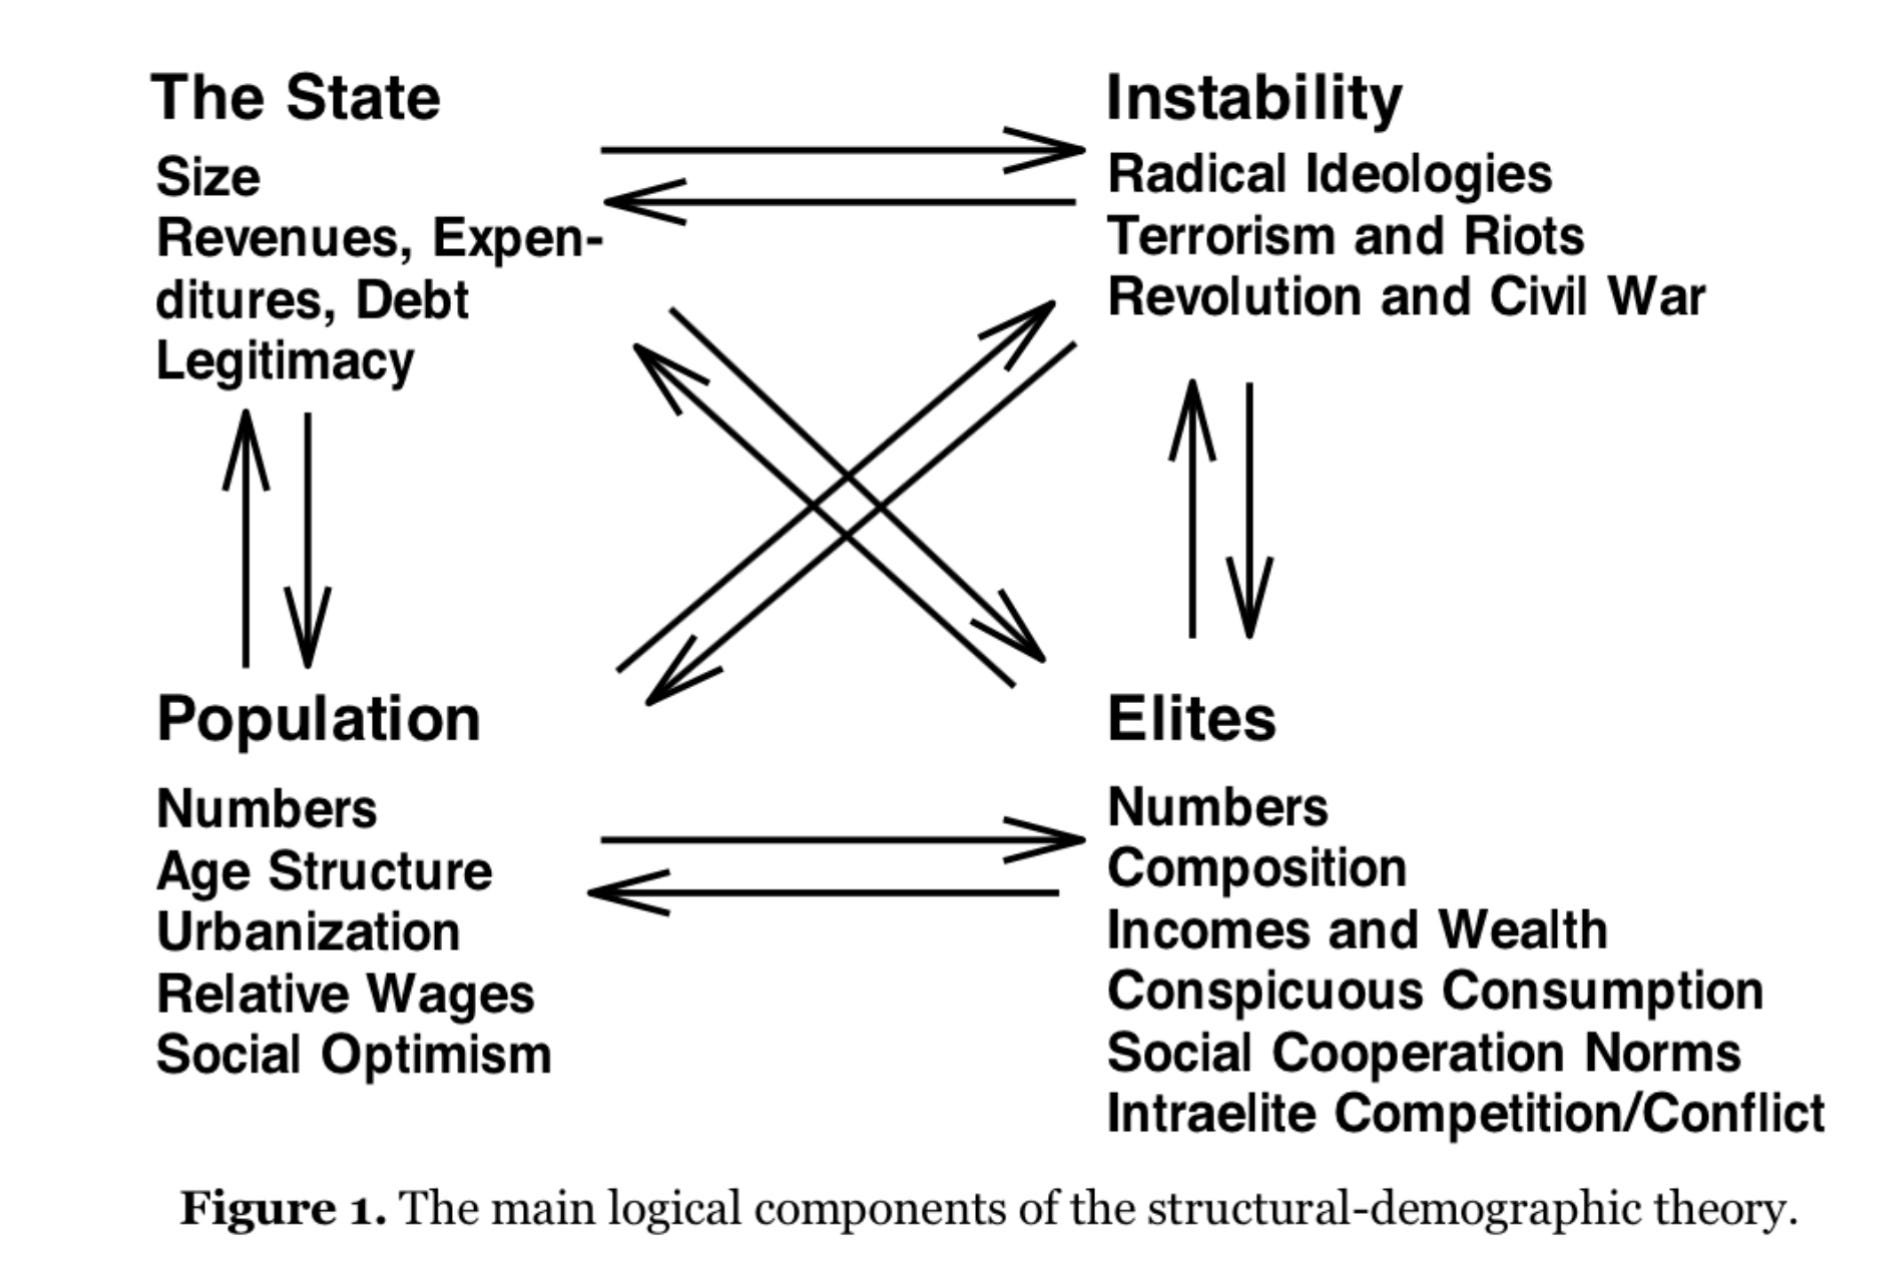

Investment:
    A portion of wealth in excess of expected wealth level rounded up gets put into an investment pool separated by pop type
    Those pops then use that money to invest in production & capital
    Pops in a location might decide to locally fund certain nonproductive enterprises by themselves depending on conditions (education, housing, security)

Popular immiseration:
    desired_wealth = 20-year moving average of actual wealth per commoner
        desired_new = desired_old + 0.05 * (current wealth - desired_old)
    base_immiseration = max(0, desired_wealth - current_wealth_per_commoner) * 0.2
    spike from shortages: +1.0 from 100% shortage
    Final = clamp (0-1) and smooth

Elite Overproduction:
    elite_job_opportunities = (total_elite_positions) + buffer
        elite_positions = elite_land / avg_elite_land_per_capita + state_employment_slots + business_slots
        buffer = 1 % of total population
    
    elite_overproduction = max(0, (elite_numbers - elite_job_opportunities) / elite_job_opportunities)

Sociopolitical Instability
    Instability = immiseration + elite overproduction
    Father and son pulse: Add/remove every 20ish years

State Capacity
    Revenue = (commoner_wealth * tax_rate_common) + (elite_surplus * tax_rate_elite)
    Spending = (elite_job_opportunities * cost_per_elite) + (military + repression) + (debt_service)
    Balance = Revenue - Spending
    Debt = Debt_old + max(0, -Annual_balance)
    State_capacity_new = (1-Debt/GDP_proxy) + (1-immiseration)


Step 0: Population: 292, Wealth: 230.77, Food Shortage: 51.82%, Wage Share: 84.94%, Inequality: 4.37, Elite Ratio: 0.0071, State Capacity: 1.00, Sociopolitical Instability: 0.16
Step 1: Population: 280, Wealth: 224.90, Food Shortage: 53.93%, Wage Share: 84.93%, Inequality: 6.01, Elite Ratio: 0.0087, State Capacity: 1.00, Sociopolitical Instability: 0.14
Step 2: Population: 269, Wealth: 217.47, Food Shortage: 55.16%, Wage Share: 84.94%, Inequality: 5.43, Elite Ratio: 0.0102, State Capacity: 1.00, Sociopolitical Instability: 0.16
Step 3: Population: 257, Wealth: 210.01, Food Shortage: 56.40%, Wage Share: 84.94%, Inequality: 4.98, Elite Ratio: 0.0117, State Capacity: 1.00, Sociopolitical Instability: 0.18
Step 4: Population: 246, Wealth: 202.54, Food Shortage: 57.65%, Wage Share: 84.94%, Inequality: 4.62, Elite Ratio: 0.0133, State Capacity: 1.00, Sociopolitical Instability: 0.19
Step 5: Population: 234, Wealth: 195.07, Food Shortage: 58.88%, Wage Share: 84.95%, Inequality: 4.51, Elite Ra

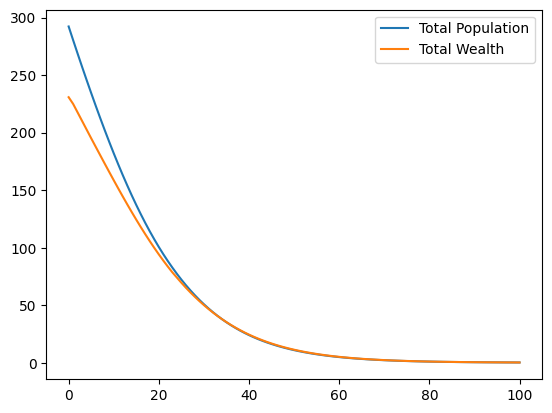

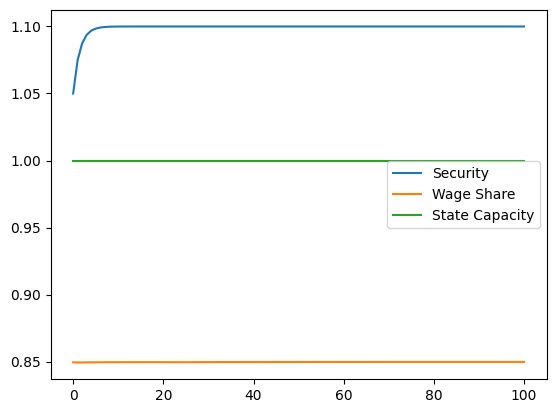

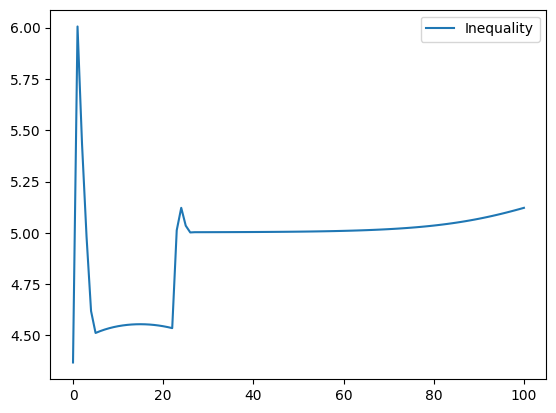

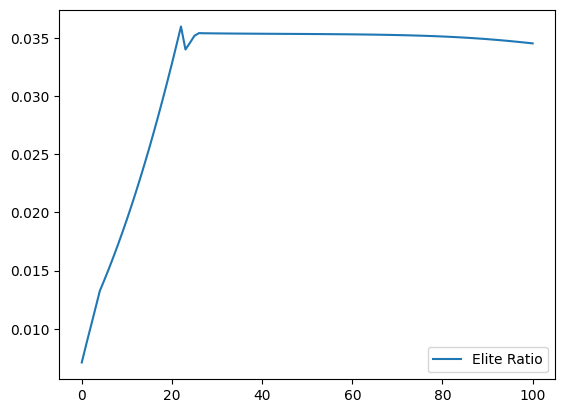

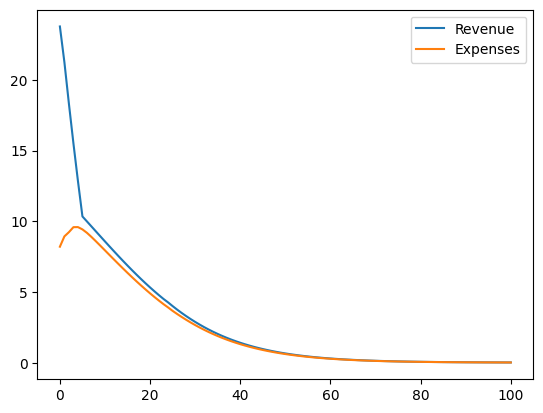

In [171]:
sim = Simulation()
sim.default_setup()
random.seed(42)
for step in range(101):
    sim.step(step=step, verbose=True)

plt.plot(sim.population_history, label="Total Population")
plt.plot(sim.wealth_history, label="Total Wealth")
plt.legend()
plt.show()

plt.plot(sim.security_history, label="Security")
plt.plot(sim.wage_share_history, label="Wage Share")
plt.plot(sim.state_capacity_history, label="State Capacity")
plt.legend()
plt.show()

plt.plot(sim.inequality_history, label="Inequality")
plt.legend()
plt.show()

plt.plot(sim.elite_ratio_history, label="Elite Ratio")
plt.legend()
plt.show()

plt.plot(sim.revenue_history, label="Revenue")
plt.plot(sim.expenses_history, label="Expenses")
plt.legend()
plt.show()

In [172]:
# Simplified version of Secular Cycles with just the core feedback loops, to test the dynamics of the model and see if it can generate realistic cycles of growth and collapse.
# It has four main variables (from 0.0 to 1.0):
# P - Population: Population relative to carrying capacity. Affected by food shortages and wealth levels. Below 0.5 is below carrying capacity, above 0.5 is above carrying capacity.
# E - Elite Overproduction: The level of elite overproduction relative to elite job opportunities. Affected by population and elite land. Above 0.0 means elites are overproducing relative to job opportunities.
# U - Sociopolitical Instability: The level of sociopolitical instability. Its effect is U^2. 0.0 means stable peace, 1.0 means civil war.
# S - State Capacity: How much the state is able to act, coerce the population, and provide public goods. 1.0 means strong and stable state, 0.0 means de-facto anarchy
#
# P:
# Supply curve to State Capacity
# Kept low by U
# E:
# Increases when P is high
# Shrinks via U
# U:
# Increases when E is high
# Shrinks when S is high
# Spikes every 40-50 years (father son cycle)
# S:
# Increases when P is high
# Decreases when U is high
# Decreases when E is high (state employing overproduced elites)
#
# Rotating Influences:
# P, S naturally grows
# P increases E (more population creates more elites)
# E decreases S (overproduced elites require state resources and create instability)
# P, E, and less S increase U (overpopulation, elite overproduction, and low state capacity all contribute to instability)
# U decreases S, E, and P

class SimpleSim:
    def __init__(
            self, 
            P=0.4, # Starting Population
            E=0.1, # Starting Elite Overproduction
            S=0.5, # Starting State Capacity
            dP_mult=1.0, # Growth multipliers
            dE_mult=1.0, 
            dS_mult=1.0, 
            dP_nmult=0.5, # Shrink multipliers (when growth is negative)
            dE_nmult=0.5, 
            dS_nmult=2.0
        ):
        self.P = P  # Population
        self.E = E  # Elite Overproduction
        self.U = 0.0  # Sociopolitical Instability
        self.U_e = 0.0  # Effective Instability (instability above state capacity)
        self.S = S  # State Capacity
        self.instability_memory = 0.0 # Memory of past instability to create inertia in the system
        
        self.phase = 0 # 0 = prosperity, 1 = strain, 2 = fracture
        
        # Random value multipliers that change every 10 steps since adjusting randomness every step cancels out the effect.
        self.P_rand = 0.0
        self.E_rand = 0.0
        self.U_rand = 0.0
        self.S_rand = 0.0

        self.P_history = []
        self.E_history = []
        self.U_history = []
        self.U_e_history = []
        self.S_history = []
        self.phase_history = []

        # Multipliers
        self.dP_mult = dP_mult
        self.dE_mult = dE_mult
        self.dS_mult = dS_mult
        self.dP_nmult = dP_nmult
        self.dE_nmult = dE_nmult
        self.dS_nmult = dS_nmult
    
    def step(self, t, randomness=0.0):

        # Population growth is based on a logistic growth model with carrying capacity influenced by state capacity and effective instability.
        carrying_cap = min(max(0.5 + self.S**2 - self.U_e * 1.0, 0.0), 1.0)
        dP = (self.P + 0.1) * (carrying_cap - self.P)
        if dP > 0:
            dP *= self.P * (1.1 - self.P) / 1.1 # Population grows slower as it approaches carrying capacity
            dP *= self.dP_mult
        else:
            dP *= (self.P+0.1)/1.1 # Population shrinks slower as it approaches 0.0
            dP *= self.dP_nmult

        
        # Elite overproduction increases with population pressure (so long as the state exists)
        # It decreases with effective instability as well as low population pressure representing how elites are the targets of violence and also high wages squeezing elite wealth.
        dE = (self.P**2 * max(0.0, self.S - self.U_e) - self.U_e**2 + min(0.0, self.P - 0.5) * 0.25)
        if dE > 0:
            dE *= (1.1 - self.E)/1.1
            dE *= self.dE_mult
        else:
            dE *= (self.E+0.2)/1.2
            dE *= self.dE_nmult

        # Sociopolitical instability increases with elite overproduction and population pressure, and decreases with state capacity. 
        # TODO: It also has periodic spikes every 40-50 years to represent father-son cycles of violence.
        #dU = (self.E - self.S + (t % 50 < 5) - 0.8 * self.U) * dU_mult
        immiseration = max(0.0, self.P - carrying_cap * 0.5) * 2 + self.E * 0.2 # Immiseration starts when population exceeds 50% of carrying capacity
        p_mobilization = min(1.0, immiseration + math.sqrt(self.instability_memory) * 0.5) # Population mobilization is based on current immiseration and memory of past instability
        e_mobilization = min(1.0, self.E + math.sqrt(self.instability_memory) * 0.5)
        unrest = p_mobilization * e_mobilization * (1 - self.S)
        dU = 0 #(-0.5 + 1 * (t % 50 < 5) - self.S) * dU_mult # Father-son cycles added to unrest equation

        # State capacity increases with population pressure and decreases with elite overproduction and sociopolitical instability. It also has a baseline growth to represent the desire to have a state.
        dS = (0.0 + self.P*(1.0 - self.U_e) - self.U_e**2 - self.E*(self.S+0.1))
        if dS > 0:
            dS *= (1.5 - self.S)/1.5
            dS *= self.dS_mult
        else:
            dS *= (self.S+0.2)/1.2
            dS *= self.dS_nmult

        # Randomness to represent unmodeled factors and add variability to the system
        if randomness > 0.0:
            if t % 10 == 0: # Adjust randomness every 10 steps to create periods of stability and instability
                self.P_rand = random.uniform(-randomness, randomness) + 1
                self.E_rand = random.uniform(-randomness, randomness) + 1
                self.U_rand = random.uniform(-randomness, randomness) + 1
                self.S_rand = random.uniform(-randomness, randomness) + 1
            
            dP *= self.P_rand
            dE *= self.E_rand
            unrest *= self.U_rand
            dS *= self.S_rand

        # Update variables with some smoothing
        self.P = max(0.0, min(1.0, self.P + dP * 0.1))
        self.E = max(0.0, min(1.0, self.E + dE * 0.1))
        self.U = max(0.0, min(1.0, self.U + dU * 0.1))
        self.S = max(0.0, min(1.0, self.S + dS * 0.1))

        self.U_e = max(0.0, min(unrest + self.U, 1.0)) # Effective instability is instability above 0.5 * state capacity
        if self.U_e > self.instability_memory:
            self.instability_memory = self.U_e
        else:
            self.instability_memory *= 0.95 # Instability memory decays over time, creating inertia in the system
            self.instability_memory = max(self.U_e, self.instability_memory-0.02) # Instability memory has a baseline decay to prevent it from getting stuck at high levels forever
        
        # Phase transitions
        if self.phase == 0 and (self.U > 0.1 or self.E > 0.5 or self.P > 0.7):
            self.phase = 1
        elif self.phase == 1 and (self.U_e > 0.5 or self.S < 0.5 or (dE < 0 and dP < 0)):
            self.phase = 2
        elif self.phase == 2 and (self.U_e < 0.05 and dP > 0 and self.S > 0.2):
            self.phase = 0

        # Record history
        self.P_history.append(self.P)
        self.E_history.append(self.E)
        self.U_history.append(self.U)
        self.U_e_history.append(self.U_e)
        self.S_history.append(self.S)
        self.phase_history.append(self.phase)

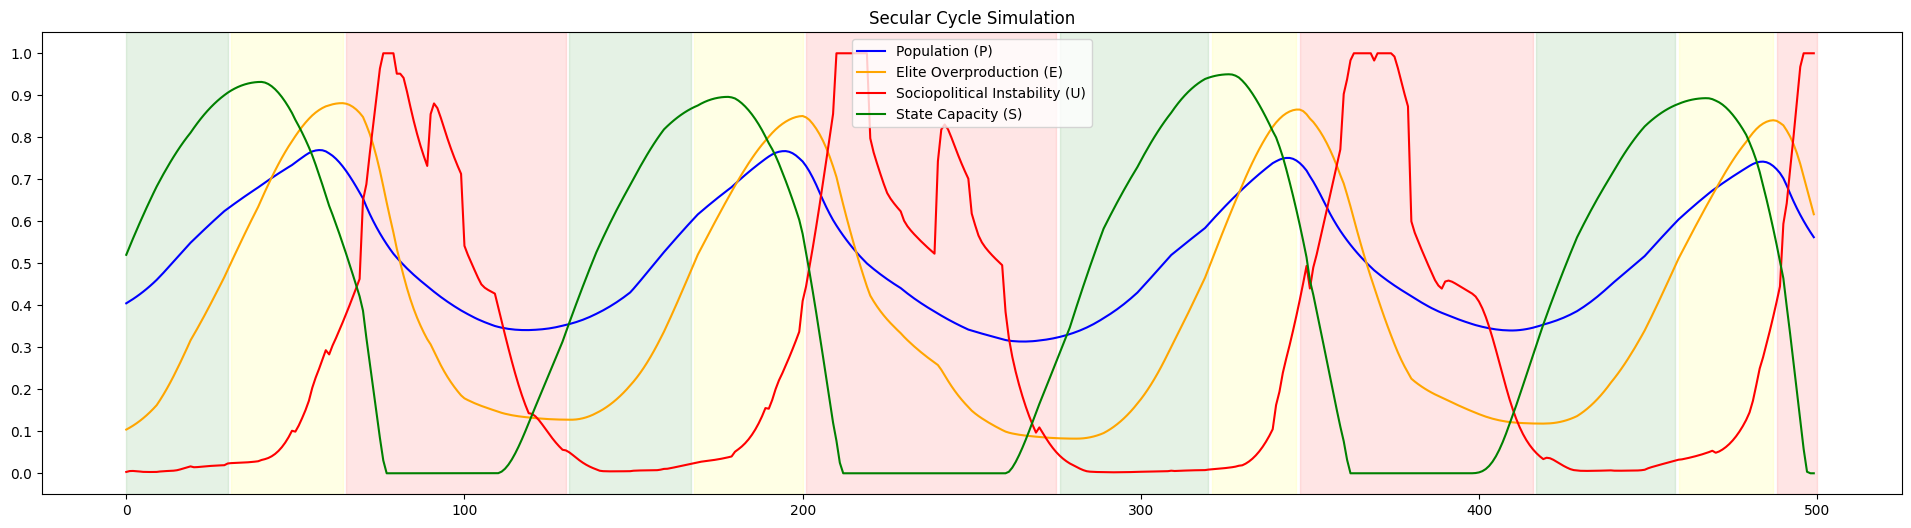

In [ ]:
def plot_phase_space(phase_history=[]):
    # build phase space plot to color the background based on the phase of the system
    # Phase 0 = prosperity (green), Phase 1 = strain (yellow), Phase 2 = fracture (red)
    phase_types = []
    phase_starts = [0]
    phase_ends = []
    for x in range(0, len(phase_history)-1):
        if phase_history[x] != phase_history[x+1]:
            phase_types.append(phase_history[x])
            phase_ends.append(x)
            phase_starts.append(x+1)
    phase_types.append(phase_history[-1])
    phase_ends.append(len(phase_history))
    
    for x in range(len(phase_types)):
        if phase_types[x] == 0:
            plt.axvspan(phase_starts[x], phase_ends[x], color='green', alpha=0.1)
        elif phase_types[x] == 1:
            plt.axvspan(phase_starts[x], phase_ends[x], color='yellow', alpha=0.1)
        elif phase_types[x] == 2:
            plt.axvspan(phase_starts[x], phase_ends[x], color='red', alpha=0.1)

def plot_simulation(
    P_history, E_history, U_history, S_history, phase_history
):
    # Implementation for plotting the simulation results
    plt.figure(figsize=(24, 6))
    plt.yticks([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
    plt.plot(P_history, label="Population (P)", color='blue')
    plt.plot(E_history, label="Elite Overproduction (E)", color='orange')
    plt.plot(U_history, label="Sociopolitical Instability (U)", color='red')
    plt.plot(S_history, label="State Capacity (S)", color='green')
    plot_phase_space(phase_history)
    plt.legend()
    plt.title("Secular Cycle Simulation")
    plt.show()
    pass

random.seed(42)

simple_sim = SimpleSim(
    P=0.4,
    E=0.1,
    S=0.5,
    dP_mult=1.0,
    dE_mult=1.0,
    dS_mult=1.0,
    dP_nmult=0.5,
    dE_nmult=0.5,
    dS_nmult=2.0
)
for t in range(500):
    simple_sim.step(t, randomness=0.2)

plot_simulation(    
    simple_sim.P_history, simple_sim.E_history, simple_sim.U_e_history, simple_sim.S_history, simple_sim.phase_history
)

In [174]:
# Recombined Model for Secular Cycles
# This model takes the former simulation and adds the core feedback loops from the simple model to create a complex, realistic, and faithful model of secular cycles.
# It has the same variables as the original simulation, but with added feedback loops and interactions based on the simple model. 
# The goal is to see if the complex model can generate realistic cycles of growth and collapse similar to the simple model, while also capturing the nuances of the original simulation.
# This will be the core of what I use as the baseline mechanics for my game, and I can add more complexity and features on top of this in the future.

# DYNAMICS TO REPLICATE:
#   These are the dynamics coded into the simple model that I want to replicate in the complex model. Certain particular relationships may be directly represented, and others will be emergent.
#   But in general these are the mathematical relationships coded above:
#
# P:
#   Carrying Capacity = 0.5 + S^2 - U_e
#   dP = (P + 0.1) * (Carrying Capacity - P)
#   immiseration = max(0, P - Carrying Capacity * 0.5) * 2 + E * 0.2
#
#   Carrying Capacity is influenced positively by State Capacity and negatively by Effective Instability.
#   Population then changes as a logistic growth model based on the carrying capacity.
#   Immiseration starts when population exceeds 50% of carrying capacity, and also increases with elite overproduction.
#   REPRESENTING P:
#       Population grows at a rough 1% rate (historically 1% population growth was common during prosperous times) when conditions are good, but with immiseration births drop
#       Starvation (lack of food) and instability (U) then can directly kill population. Additional factors representing famine and disease would also be represented with immiseration.
#       Immiseration would be generated from a combination of factors such as food shortages, wealth decline (from expectation), elite overproduction, and inequality 
#           (which would intensify the effect such that even if the average wealth level of commoners is fine, if inequality is high, then a large portion of commoners would still be affected).
#       High population relative to job opportunities reduces the wage share, which increases inequality, decreases wealth of commoners, and as such increases immiseration.
#   HOW THIS REPLICATES THE SIMPLE MODEL:
#       Population growth would follow the near exponential curve of the early logistic model (though not exact, which is fine) with carrying capacity instead reflecting the output and productivity of the land and economy.
#       The latter half of the logistic growth curve would be reproduced via the effect of immiseration on population growth, even without instability directly killing population (as can be replicated in the simple model)
#       Immiseration only comes about as a result of high population putting pressure on resources. The more population there is, not only do resources become more scarce, 
#           but the wealth generated gets redirected increasingly towards elites, which furthers immiseration.
#       Final population pressure is then represented by the population relative to economic capacity with 0.5 being equality, thus recreating the variable P, only this isn't on a pure 0 to 1 scale as the upper amount is technically unbounded
#
# E:
#   dE = + P^2 * max(0, S - U_e) 
#        - U_e^2 
#        - max(0, 0.5 - P) * 0.25
#
#   Elite overproduction increases disproportionately with population pressure, but only when the state has the capacity (Condition existing to cut elite production to zero in times of crisis)
#   It decreases with instability as elites are the targets of violence in unstable times
#   It also decreases with low population pressure representing how high wages squeeze lower-end elites and force them to either downgrade or fight (the latter of which is not represented yet...)
#   REPRESENTING E:
#       Elites grow at a disproportionately fast rate compared to the population (likely 2%+) due to lower child mortality rates and greater access to resources, but bear less children when facing direct threat (instability).
#       Elites grow faster with higher inequality and can decline with low inequality.
#       Job opportunities for elites are based on elite land and state capacity. However the jobs provided for by the state only exist so long as the state can support them (based on state capacity, S).
#       Elites are disproportionately killed by instability, though are less affected by famine, disease, and other things that affect the general population.
#   HOW THIS REPLICATES THE SIMPLE MODEL:
#       Because when population is low, wages are high and thus the inequality measure pumps elites into commoners as elites cannot extract much surplus from the population. But when high, the opposite occurs.
#       The natural population growth from elites is also higher than commoners, which helps drive the growth of elites during prosperous times. This can be surpressed during times of instability and uncertainty, which can represent the S - U_e term.
#       Instability killing elites represents the - U_e^2 term. In-fact it'd almost be a direct copy.
#       Final elite overproduction is then represented by the number of excess elites relative to elites total, thus replicating the variable E.
#
# U:
#   Population Mobilization = min(1, Immiseration + sqrt(Instability Memory) * 0.5)
#   Elite Mobilization = min(1, E + sqrt(Instability Memory) * 0.5)
#   Unrest = Population Mobilization * Elite Mobilization * (1 - S)
#
#   Unrest is a function of popular and elite anger and state collapse. A strong state suppresses unrest, but when the state is weak, then unrest can grow based on how mobilized the population and elites are.
#   Mobilization for the population is based on immiseration and for elites, overproduction, but both are also influenced by memory of past instability to help prolong instability and create inertia in the system.
#   REPRESENTING U:
#       Unrest and instability would be based on a combination of popular immiseration and elite overproduction, as well as current state capacity.
#       Instability memory would be increased with current instabiltity to match it, but then when instability goes down, the memory would decay slowly over time.
#   HOW THIS REPLICATES THE SIMPLE MODEL:
#       It does, for the moment, nothing different than the simple model. This may change as I add in "security" and "control" to locations, but for now it's a direct copy.
#       Any future changes will have to preserve the dynamics here, though that should be relatively easy as this is a pretty straightforward relationship. 
#       And the only thing that would change is the (1-S) term, of which the only change might literally be that S goes from meaning "State Capacity" to "Security" where security is itself partially derived from state capacity (but other factors too) 
#
# S:
#   dS = + P*(1.0 - U_e) 
#        - U_e^2 
#        - E*(S+0.1)
#
#   State capacity grows with population pressure, representing taxation, but collection is less effective with high instability
#   It decreases with unrest due to the cost of suppression and with elite overproduction taking state resources (though this is not a factor when the state doesn't exist - allowing the state to exist partially in the fracture phase)
#   REPRESENTING S:
#       State capacity is not necessarily a simulation variable in of itself (as it is in the simple model), but emerges from the fiscal, miltary, and administrative abilities of the state
#       The state collects revenue in the form of taxing wealth generated from economic activity, so higher population = more economic activity = more revenue for the state. 
#       This is modulated by instability where high instability reduces the state's ability to collect taxes (represented by the effective taxation rate)
#           This will eventually be determined on a location by location basis based on the control and security of the location as well as if it's actually controlled (say in a civil war, occupation, or rebellion scenario)
#       The State then spends its revenue on a combination of military and public goods.
#           When instability is high, more of the state's resources are diverted towards repression and suppression of unrest
#           When you have excess elites, the state will try to employ them to keep them from causing trouble. 
#               In game this can actually potentially temporarily increase military capabilities (to a point, as overproduced elites can bicker with each other. See France during the Hundred Years War)
#       When the state spends more than it earns, it accumulates debt. At a certain point, it is deemed too risky to lend to, which can lead to default, and thus the inability to suppress unrest or pay for public goods and elite jobs
#       State capacity is thus one of the most complicated variables to derive, as it is based on a combination of revenue, expenses, debt, and the ability to effectively use resources to suppress unrest and provide public goods.
#           Fiscal Capacity = 0.5 * (Ordinary Revenue + Extraordinary Revenue - Expenses) / Expenses + (Debt Capacity + Savings - Debt) / (Debt Capacity + 2 * Expenses)
#           Ordinary Revenue = Taxation Rate * Wealth Generated by Population
#           Extraordinary Revenue = Revenue that *can* be derived from the state 1. hiking taxes, 2. printing money/debasing currency, 3. seizing wealth from elites, 4. selling off state assets. Each calculated to roughly account what can be done in one tick.
#               Using extraordinary revenues will decrease the ability to use them in the near-term future and possibly cause long-term problems. Some are less problematic (hiking taxes) but their use can heavily deteriorate medium-term fiscal capacity.
#           Expenses = Cost of government + repression + employing elites + interest on debt
#           Debt Capacity = The amount of debt the state can take on before lenders refuse to lend
#           Debt = Accumulated debt from previous deficits
#           Savings = When the state has a surplus in excess of debt, it can save up to 2 times its expenses. This helps represent ancient states' reliance on saving up to go fight wars or handle crises.
#           When the state has a deficit, it can take on debt up to its debt capacity. If it exceeds its debt capacity, it defaults.
#           NOTE: Depending on laws, default could also wipe out debt (like the repudiation of debt in medieval times), which would allow the state to recover capacity more quickly but hike interest rates and make it harder to borrow.
#                 So the severe US indebtedness is not indicative of typical situations.\
#        Coercion Capacity = Willingness & ability of the state to use violence to suppress unrest. For now it's set to 1.0, but will eventually be derived from army size, security, and other factors.
#        It is assumed so long as the state is able to pay its financial obligations, it will maintain all its administrative and welfare duties, but as fiscal capacity declines, its ability to pay will deteriorate.
#        Final State Capacity = Fiscal Capacity * Coercion Capacity
#   HOW THIS REPLICATES THE SIMPLE MODEL:
#       Because State Capacity is a derived value in the complex model, it is very different from the floating value in the simple model.
#       The increase of population increasing state capacity is represented by the increase in revenue from taxation (which then gets blocked by instability).
#       Unrest and elite overproduction increases state expenses, which can reduce state capacity if it leads to deficits and debt.
#       Whether the state chooses to no longer suppress violence or support elites, or it just can't because it defaults, the effect is the same in that it reduces state capacity.
#       Debt, Savings, and Extraordinary Revenues are all mechanics that help the state to manage or delay crises, but can make the crisis worse. 
#           Importantly, they cannot be used indefinitely. So their inclusion doesn't alter the dynamics, but adds more depth and realism to the model.

class RPop:
    def __init__(self, name, n):
        self.name = name
        self.population = n
        self.wealth = 0.0
        self.wealth_level = 0
        self.desired_wealth_level = 0.0
        self.taxes = 0.0
        self.government_benefits = 0.0

class RecombinedSim:
    def __init__(
            self, 
            commoner_pop=100, # Starting Commoner Population
            elite_pop=1.0, # Starting Elite Population
            land_area=100, # Starting Land Area
            elite_share=0.2, # Starting Elite Land Share
            dP_mult=1.0, # Growth multipliers (idk if these are necessary yet)
            dE_mult=1.0, 
            dS_mult=1.0, 
            dP_nmult=0.5, # Shrink multipliers (when growth is negative)
            dE_nmult=0.5, 
            dS_nmult=2.0
        ):
        # Simple Model Variables
        # These values will be derived from the base-truth simulation, but they will also feed back into the base-truth simulation to help replicate the dynamics of secular cycles.
        # They will also be used to graph the results and identify phases of the cycle, which can be used for game mechanics and events.
        self.P = 0.0  # Population
        self.E = 0.0  # Elite Overproduction
        self.U = 0.0  # Sociopolitical Instability
        self.S = 0.0  # State Capacity
        self.instability_memory = 0.0 # Memory of past instability to create inertia in the system
        
        self.phase = 0 # 0 = prosperity, 1 = strain, 2 = fracture

        self.P_history = []
        self.E_history = []
        self.U_history = []
        self.S_history = []
        self.phase_history = []

        # Base-Truth Simulation Variables
        self.population = 0.0
        self.total_wealth = 0.0
        self.pops = {}
        self.land_area = land_area  # total arable land
        self.food_production_per_land = 2.0  # food produced per unit land
        self.food_consumption_per_capita = 1.0  # food consumed per person
        self.productivity = 2.0  # base productivity of land
        self.wealth_per_land = 1.0  # wealth generated per unit land
        self.common_land = land_area * (1 - elite_share)
        self.elite_land = land_area * elite_share

        self.food_production = 0.0
        self.food_consumption = 0.0
        self.food_shortage = 0.0

        self.wage_share = 0.0
        self.popular_immiseration = 0.0
        self.population_ratio = 0.0

        self.elite_job_opportunities = 0.0
        self.elite_excess = 0.0

        self.taxation_rate = 0.0 # Idk if I need to include a taxation rate per-se or if I can just calculate it based on the revenue needed to maintain state capacity, but I'll include it for now as a separate variable to make it easier to adjust and experiment with.
        self.revenue = 0.0
        self.expenses = 0.0
        self.state_jobs = 0.0
        self.debt = 0.0
        self.debt_capacity = 0.0
        self.savings = 0.0
        self.interest = 0.0
        self.extraordinary_revenue_exhaustion = 0.0 # A measure of how much the state has used extraordinary revenues recently

        # History for graphing & analysis
        self.population_history = []
        self.wealth_history = []
        self.wage_share_history = []
        self.inequality_history = []
        self.revenue_history = []
        self.expenses_history = []
        self.debt_history = []

        # Initialize Things
        self.add_pop("Commoners", commoner_pop)
        self.add_pop("Elites", elite_pop)

        self.taxation_rate = 0.2 # To note, commoner taxation is half of elite taxation.

        self.land_jobs = get_job_capacity(self.land_area, method_applied=self.productivity-1, method_exponent=0.95)
        self.wage_share = get_wage_share(self.pops["Commoners"].population, self.land_jobs, self.land_jobs * (self.common_land/self.land_area))
        self.micro_economy_step()
        self.state_capacity_step()
        for pop in self.pops.values():
            pop.wealth_level = get_wealth_level(pop.population, pop.wealth + pop.government_benefits - pop.taxes)
            pop.desired_wealth_level = pop.wealth_level
        self.derive_secular_cycle_variables()
    
    def add_pop(self, name, n):
        pop = RPop(name, n)
        self.pops[name] = pop
        self.population += n
    
    def adjust_population(self, name, delta):
        if name not in self.pops:
            return
        
        self.pops[name].population = max(0.0, self.pops[name].population + delta)
        self.population = max(0.0, self.population + delta)
    
    def land_transfer(self, land: float):
        if land == 0:
            return
        
        # Bound land to the amount of land available for transfer
        land = max(-self.elite_land, min(self.common_land, land))

        self.common_land -= land
        self.elite_land += land

    def social_mobility(self, pop: float, land_rate: float = 2.0):
        if pop == 0:
            return

        # Bound pop to the amount of population available for promotion
        pop = max(-self.pops["Elites"].population, min(self.pops["Commoners"].population, pop))

        self.pops["Commoners"].population -= pop
        self.pops["Elites"].population += pop

        # Portion of land goes with the promoted/demoted pops. Land rate determines disproportionality of land transfer.
        if land_rate == 0:
            return

        if pop > 0:
            land_transfer_amount = (pop / self.pops["Commoners"].population) * self.common_land * land_rate if self.pops["Commoners"].population > 0 else 0.0
        else:
            land_transfer_amount = -1 * (pop / self.pops["Elites"].population) * self.elite_land / land_rate if self.pops["Elites"].population > 0 else 0.0
        self.land_transfer(land_transfer_amount)
    
    def get_inequality(self):
        elite_per_capita = self.pops["Elites"].wealth / self.pops["Elites"].population if self.pops["Elites"].population > 0 else 0.0
        commoner_per_capita = self.pops["Commoners"].wealth / self.pops["Commoners"].population if self.pops["Commoners"].population > 0 else 0.0

        return elite_per_capita / commoner_per_capita if commoner_per_capita > 0 else float('inf')
    
    def get_elite_ratio(self):
        elite_population = self.pops["Elites"].population if "Elites" in self.pops else 0.0
        common_population = self.pops["Commoners"].population if "Commoners" in self.pops else 0.0

        return elite_population / common_population if common_population > 0 else float('inf')
    
    def micro_economy_step(self):
        # Commoner Allocation
        farmable_land = self.land_area * min(1.0, max(0.5, 0.75 + 0.5 * (self.S ** 2 - self.U))) # Farmable land is reduced by insecurity (TODO: Change this to be based directly on security rather than overall state capacity/instability)

        self.land_jobs = get_job_capacity(farmable_land, method_applied=self.productivity-1, method_exponent=0.95) # Number of agricultural jobs
        
        commoner_land_pull = self.productivity * self.land_jobs * (self.common_land / self.land_area)
        elite_land_pull = self.productivity * self.land_jobs * (self.elite_land / self.land_area) * ((1+self.wage_share) / 2.0)
        
        self.land_pull = commoner_land_pull + elite_land_pull
        self.total_commoner_pull = self.land_pull # for now, we can add other pulls (like urban jobs) to this in the future

        self.commoners_on_land = self.pops["Commoners"].population * (self.land_pull / self.total_commoner_pull) if self.total_commoner_pull > 0 else 0.0

        # Production
        prod_final = self.productivity
        land_prod = get_land_productivity(farmable_land, self.commoners_on_land, base_productivity=prod_final) * self.commoners_on_land
        
        # Wealth Allocation
        # From Work
        work_value = land_prod * self.wealth_per_land
        self.pops["Commoners"].wealth = work_value * self.wage_share
        
        # From Ownership
        self.pops["Commoners"].wealth += work_value * (1 - self.wage_share) * (self.common_land / self.land_area) 
        self.pops["Elites"].wealth = work_value * (1 - self.wage_share) * (self.elite_land / self.land_area) 
        self.total_wealth = work_value
        
        # Food Calculation
        self.food_production = land_prod * self.food_production_per_land
        self.food_consumption = sum(pop.population * self.food_consumption_per_capita for pop in self.pops.values())
        self.food_shortage = max(0.0, self.food_production - self.food_consumption) / self.food_consumption if self.food_consumption > 0 else 0.0

    def popular_immiseration_step(self):
        popular_immiseration = (
            self.food_shortage * 0.5 
            + max(0.0, (self.pops["Commoners"].desired_wealth_level - self.pops["Commoners"].wealth_level) * 0.2)
            + max(0.0, self.E - 0.25) * 0.2
        )
        popular_immiseration *= max(1.0, math.log(self.get_inequality() + 1) - 2.4) # Inequality intensifies immiseration after about a 10:1 ratio between elites and the rest of the population.
        popular_immiseration = max(min(popular_immiseration, 1.0), 0.0)
        
        # Any shortage causes misery
        if self.food_shortage > 0.0:
            popular_immiseration += 0.1

        # Populace become content with their desired wealth level (also helps get PI to 0)
        if self.pops["Commoners"].wealth_level > self.pops["Commoners"].desired_wealth_level:
            popular_immiseration -= 0.1
        
        self.popular_immiseration = min(max(0.0, self.popular_immiseration * 0.5 + popular_immiseration * 0.5), 1.0) # smoothing
        self.population_ratio = self.population / (self.land_area * self.productivity) if (self.land_area * self.productivity) > 0 else float('inf')

    def elite_overproduction_step(self):
        buffer = 0.005 * self.population
        self.elite_job_opportunities = self.land_jobs * (self.elite_land / self.land_area) * 0.01 + self.state_jobs + buffer
        self.elite_excess = max(0.0, self.pops["Elites"].population - self.elite_job_opportunities + self.state_jobs)
        self.elite_overproduction = max(0.0, self.pops["Elites"].population - self.elite_job_opportunities) / (self.elite_job_opportunities + 1e-8)
    
    def state_capacity_step(self):
        self.taxation_rate = 0.1 # Government takes 10% of surplus
        self.debt_capacity = self.total_wealth * 0.1 # State can take on debt up to 10% of total wealth. This is arbitrary, but probably realistic for early-modern states

        repression = self.U ** 2 * self.S
        effective_taxation_rate_commoners = self.taxation_rate * (1.0 - self.U) * 0.5
        effective_taxation_rate_elites = self.taxation_rate * (1.0 - self.U)
        
        self.pops["Commoners"].taxes = effective_taxation_rate_commoners * self.pops["Commoners"].wealth
        self.pops["Elites"].taxes = effective_taxation_rate_elites * self.pops["Elites"].wealth

        elite_desired_wealth = wealth_req[round(self.pops["Elites"].desired_wealth_level)]
        self.pops["Elites"].government_benefits = self.state_jobs * elite_desired_wealth

        interest = min(self.debt * 0.05, self.revenue * self.S) # State debt payments is 1/n^2 of its capacity. 
        # This means lower capacity is able to pay less, which represents the difficulty of paying debt during times of crisis. 
        # It also means that if the state collapses (capacity goes to 0), it effectively defaults on its debt.
        # It also makes it easier for the state to recover from collapse if conditions improve, as the debt burden is reduced during collapse.

        self.revenue = self.pops["Commoners"].taxes + self.pops["Elites"].taxes
        self.expenses = self.state_jobs * elite_desired_wealth + interest + repression * self.population * elite_desired_wealth * 0.1
        

    def adjustments_step(self):
        # Government adjustments
        self.state_jobs = self.pops["Elites"].population * 0.05 + self.elite_excess * self.S * 0.2 # Military + State tries to absorb excess elite population

        net_budget = self.revenue - self.expenses
        extraordinary_revenue_used = False
        if net_budget < 0:
            if self.S < 1.0:
                # Try extraordinary revenue
                extraordinary_revenue = min(-net_budget, self.total_wealth * 0.1 * (1.0 - self.extraordinary_revenue_exhaustion))
                self.extraordinary_revenue_exhaustion += extraordinary_revenue / (self.total_wealth * 0.1 + 1e-8)
                self.extraordinary_revenue_exhaustion = min(self.extraordinary_revenue_exhaustion, 1.0) # Cap exhaustion at 100%
                
                net_budget += extraordinary_revenue
                self.revenue += extraordinary_revenue
                extraordinary_revenue_used = True

            if net_budget < 0:
                if self.savings > 0.0:
                    savings_used = min(-net_budget, self.savings)
                    self.savings -= savings_used
                    net_budget += savings_used
                
                if self.debt < self.debt_capacity:
                    self.debt += -net_budget
        else:
            debt_repayment = min(net_budget, self.debt)
            self.debt = max(0.0, self.debt - debt_repayment) # Pay down debt if there's a surplus

            if net_budget > debt_repayment:
                self.savings += net_budget - debt_repayment # Save any remaining surplus after paying down debt, up to 2 times expenses
                self.savings = min(self.savings, 2 * self.expenses)

        if not extraordinary_revenue_used:
            self.extraordinary_revenue_exhaustion = max(0.0, self.extraordinary_revenue_exhaustion - 0.05) # Recovery from extraordinary revenue use

        # Wage Adjustment
        self.wage_share = get_wage_share(self.pops["Commoners"].population, self.land_jobs, self.land_jobs * (self.common_land/self.land_area))

        # Goods Shortages and Population Growth
        for pop in self.pops.values():
            pop.wealth_level = get_wealth_level(pop.population, pop.wealth - pop.taxes + pop.government_benefits) # Wealth level is based on disposable wealth after taxes and benefits
            shortage_modifier = get_shortage_modifier(pop.wealth_level, self.food_shortage)

            birth_rate = 0.01 * (1.0 + self.S) + 0.001 * pop.wealth_level
            death_rate = 0.01 + 0.1 * shortage_modifier + self.U ** 2 * 0.01
            if pop.name == "Elites":
                birth_rate += 0.01 * max(0.0, self.S - self.U)
                death_rate += 0.1 * self.U ** 2 # Elites are more affected by instability, which can cause death or demotion
            else:
                birth_rate -= 0.01 * self.popular_immiseration
            
            population_change = (birth_rate - death_rate) * pop.population

            self.adjust_population(pop.name, population_change)
        
        # Elites downgrade when they're poor
        if self.get_inequality() < 5.0:
            rate = -0.2 * (5.0 - self.get_inequality())
            self.social_mobility(pop=rate * self.pops["Elites"].population, land_rate=2.0)

        # New elites form from commoners
        if self.common_land > 0.0 and self.U < 0.25:
            rate = 0.01 * self.get_inequality()
            self.social_mobility(pop=rate * (self.pops["Commoners"].population * 0.01 + self.pops["Elites"].population), land_rate=20.0)

            if self.elite_job_opportunities - self.state_jobs > self.pops["Elites"].population:
                self.social_mobility(pop=self.elite_job_opportunities * 0.01, land_rate=20.0)

        # Correct values in case of issues
        self.population = sum(pop.population for pop in self.pops.values())
    
    def derive_secular_cycle_variables(self):
        # Derive simple model variables from the base-truth simulation variables
        # NOTE: These values are bounded to [0.0, 1.0] though the base truth may go outside of these bounds. This is to keep the simple model variables interpretable and to prevent extreme values from dominating the dynamics.
        #       Not to mention make them representable as percentages for the game as well as graphing together.
        
        # Population relative to carrying capacity, where 0.5 is carrying capacity. This technically risks going above 1.0, but it should be fine so long as the dynamics at 1.0 population pressure are properly represented.
        # TODO: Represent carrying capacity as a function of total productive job capacity rather than just land.
        self.P = 0.5 * self.population / (self.land_jobs) if (self.land_jobs) > 0 else 1.0

        # Elite overproduction relative to elite count, where 0.0 means no overproduction, 1.0 means every elite is jobless
        self.E = (self.pops["Elites"].population - self.elite_job_opportunities) / (self.pops["Elites"].population + 1e-8)
        
        # State capacity as derived from the base-truth simulation's variables for revenue, expenses, debt, and repression. 
        # This is a bit more complex to derive, but we can use a combination of these variables to create a state capacity variable that reflects the state's ability to act and provide public goods.
        # Fiscal Capacity = 0.5 * (Ordinary Revenue + Extraordinary Revenue - Expenses) / Expenses + (Debt Capacity + Savings - Debt) / (Debt Capacity + 2 * Expenses)
        extraordinary_revenue = self.total_wealth * 0.1 * (1 - self.extraordinary_revenue_exhaustion) # The state can extract up to 10% of total wealth in extraordinary revenue, but this is not sustainable.
        
        fiscal_capacity = 0.5 * (self.revenue + extraordinary_revenue - self.expenses) / (self.expenses + 1e-8) + max(0.0, self.debt_capacity + self.savings - self.debt / (self.debt_capacity +self.expenses * 2))
        fiscal_capacity = max(0.0, min(fiscal_capacity, 1.0)) # Bound fiscal capacity to [0.0, 1.0]

        military_capacity = fiscal_capacity # TODO: Add in military capacity as a separate factor based on army size, security, and other factors.

        self.S = math.sqrt(fiscal_capacity * military_capacity)
        
        # Sociopolitical instability based on popular immiseration and elite overproduction, where 0.0 means stable peace and 1.0 means civil war.
        # Calculated after S & E as they are needed to calculate unrest
        p_mobilization = min(1.0, self.popular_immiseration + math.sqrt(self.instability_memory) * 0.5) # Population mobilization is based on current immiseration and memory of past instability
        e_mobilization = min(1.0, self.E + math.sqrt(self.instability_memory) * 0.5)
        unrest = p_mobilization * e_mobilization * (1 - self.S)
        self.U = unrest

        if self.U > self.instability_memory:
            self.instability_memory = self.U

        # Min/Max values to keep variables within [0.0, 1.0] for easier interpretation and to prevent extreme values from dominating the dynamics.
        self.P = min(max(self.P, 0.0), 1.0)
        self.E = min(max(self.E, 0.0), 1.0)
        self.U = min(max(self.U, 0.0), 1.0)
        self.S = min(max(self.S, 0.0), 1.0)

    def phase_update(self):
        dE = 0.0
        dP = 0.0
        if len(self.E_history) > 1:
            dE = self.E_history[-1] - self.E_history[-2]
        if len(self.P_history) > 1:
            dP = self.P_history[-1] - self.P_history[-2]

        if self.phase == 0 and (self.U > 0.1 or self.E > 0.5 or self.P > 0.7):
            self.phase = 1
        elif self.phase == 1 and (self.U > 0.5 or self.S < 0.5 or (dE < 0 and dP < 0)):
            self.phase = 2
        elif self.phase == 2 and (self.U < 0.05 and dP > 0 and self.S > 0.2):
            self.phase = 0
        
    def record_history(self):
        total_population = sum(pop.population for pop in self.pops.values())
        total_wealth = sum(pop.wealth for pop in self.pops.values())
        inequality = self.get_inequality()

        self.population_history.append(total_population)
        self.wealth_history.append(total_wealth)
        self.wage_share_history.append(self.wage_share)
        self.inequality_history.append(inequality)

        self.revenue_history.append(self.revenue)
        self.expenses_history.append(self.expenses)

        self.P_history.append(self.P)
        self.E_history.append(self.E)
        self.U_history.append(self.U)
        self.S_history.append(self.S)
        self.phase_history.append(self.phase)

    def step(self, step=0, verbose=False):
        print(f"Step {step}: Population={self.population:.2f}, Wealth={self.total_wealth:.2f}, Inequality={self.get_inequality():.2f}") if verbose else None
        print(f"Revenue: {self.revenue:.2f}, Expenses: {self.expenses:.2f}, Savings: {self.savings:.2f}, Debt: {self.debt:.2f}, Debt Capacity: {self.debt_capacity:.2f}") if verbose else None
        print(f" Commoners: Pop: {self.pops['Commoners'].population:.2f}, Wealth: {self.pops['Commoners'].wealth:.2f}, Wealth Level: {self.pops['Commoners'].wealth_level:.2f}, Desired Wealth Level: {self.pops['Commoners'].desired_wealth_level:.2f}, Taxes: {self.pops['Commoners'].taxes:.2f}, Benefits: {self.pops['Commoners'].government_benefits:.2f}") if verbose else None
        print(f" Elites: Pop: {self.pops['Elites'].population:.2f}, Wealth: {self.pops['Elites'].wealth:.2f}, Wealth Level: {self.pops['Elites'].wealth_level:.2f}, Desired Wealth Level: {self.pops['Elites'].desired_wealth_level:.2f}, Taxes: {self.pops['Elites'].taxes:.2f}, Benefits: {self.pops['Elites'].government_benefits:.2f}") if verbose else None
        print(f" Immiseration: {self.popular_immiseration:.2f}") if verbose else None
        self.micro_economy_step()
        self.popular_immiseration_step()
        self.elite_overproduction_step()
        self.state_capacity_step()
        self.adjustments_step()
        self.derive_secular_cycle_variables()
        self.phase_update()
        self.record_history()


Step 0: Population=50.50, Wealth=60.00, Inequality=8.15
Revenue: 3.23, Expenses: 0.00, Savings: 0.00, Debt: 0.00, Debt Capacity: 6.00
 Commoners: Pop: 50.00, Wealth: 55.48, Wealth Level: 3.00, Desired Wealth Level: 3.00, Taxes: 2.77, Benefits: 0.00
 Elites: Pop: 0.50, Wealth: 4.52, Wealth Level: 10.00, Desired Wealth Level: 10.00, Taxes: 0.45, Benefits: 0.00
 Immiseration: 0.00
Step 1: Population=43.02, Wealth=66.67, Inequality=6.57
Revenue: 3.58, Expenses: 0.00, Savings: 0.00, Debt: 0.00, Debt Capacity: 6.67
 Commoners: Pop: 42.49, Wealth: 61.64, Wealth Level: 3.00, Desired Wealth Level: 3.00, Taxes: 3.08, Benefits: 0.00
 Elites: Pop: 0.53, Wealth: 5.02, Wealth Level: 11.00, Desired Wealth Level: 10.00, Taxes: 0.50, Benefits: 0.00
 Immiseration: 0.54
Step 2: Population=36.00, Wealth=59.64, Inequality=5.68
Revenue: 3.22, Expenses: 0.18, Savings: 0.35, Debt: 0.00, Debt Capacity: 5.96
 Commoners: Pop: 35.47, Wealth: 54.98, Wealth Level: 3.00, Desired Wealth Level: 3.00, Taxes: 2.75, Bene

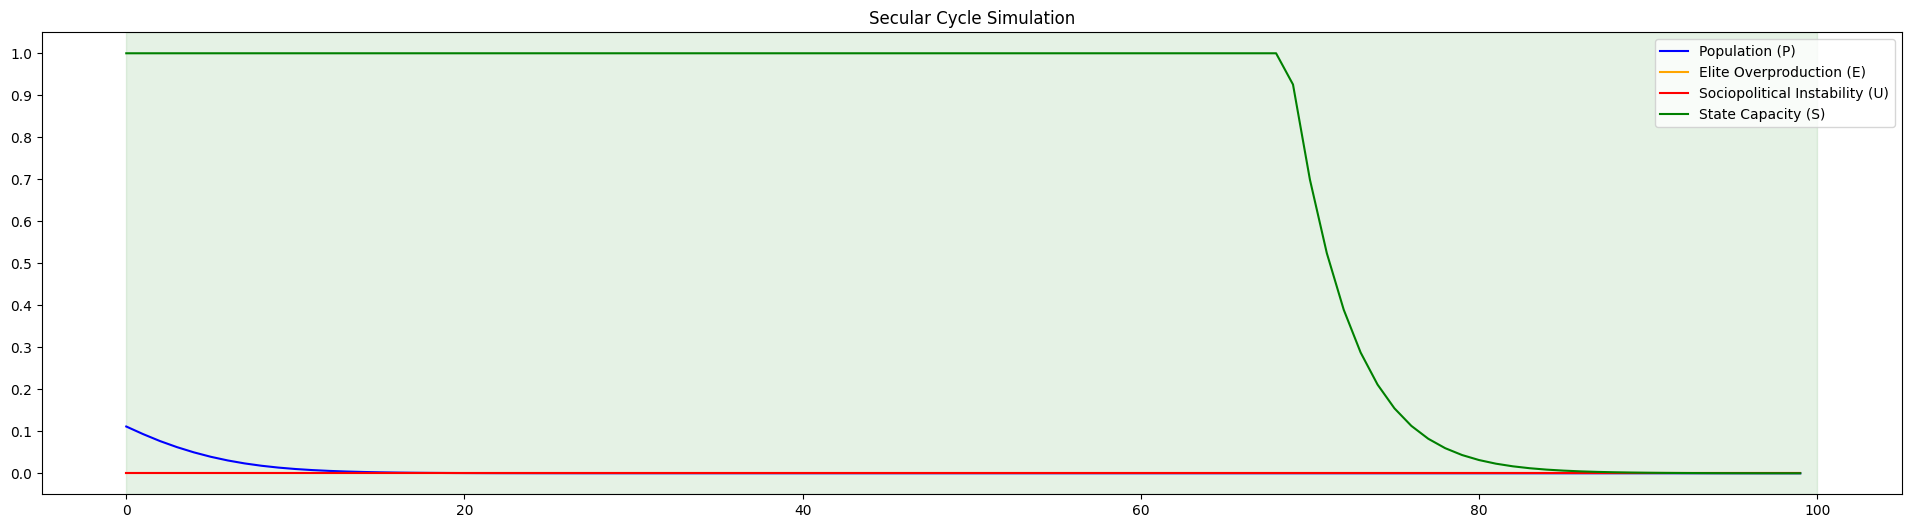

In [175]:
# TODO: Find out why immiseration spikes so much in the beginning

random.seed(42)

recombined_sim = RecombinedSim(
    commoner_pop=50.0,
    elite_pop=0.5,
    land_area=100.0,
    elite_share=0.5,
    dP_mult=1.0,
    dE_mult=1.0,
    dS_mult=1.0,
    dP_nmult=0.5,
    dE_nmult=0.5,
    dS_nmult=2.0
)
for t in range(100):
    recombined_sim.step(t, verbose=True)

plot_simulation(    
    recombined_sim.P_history, recombined_sim.E_history, recombined_sim.U_history, recombined_sim.S_history, recombined_sim.phase_history
)

# Unified Model: Secular Cycles grounded in the Economy

The `SimpleSim` above reliably produces ~2-3 century boom -> strain -> fracture cycles from
four normalized gauges `P, E, U, S` in `[0, 1]`. The goal now is to ground those gauges in the
game's actual economy (land / food / wealth / pops) **without losing that reliability**.

**Strategy (one quarter at a time):** a single `SecularSim` class holds both the four gauges
*and* the agrarian economy. Each gauge has a **mode flag**: `"ode"` (use the proven `SimpleSim`
rule) or `"econ"` (derive from the economy). We flip exactly **one** flag per stage and gate
each stage against `SimpleSim`'s cycle shape, so any lost stability is attributable to that one
subsystem.

- **Stage 0 (this cell block):** `SecularSim` with all four gauges in `"ode"` mode. Must
  reproduce `SimpleSim` *exactly*. This is the golden regression anchor.
- **Stage 1:** add the agrarian economy in *shadow mode* (driven by the gauges, feeds nothing back).
- **Stage 2:** mechanize `P` (population from real births/deaths). Then `E`, then `S`, then refine `U`.

Per-tick order: (1) economy micro-step from current gauges -> (2) compute econ candidates ->
(3) update each gauge per its mode flag -> (4) update `U_e`, memory, phase, history.


In [176]:
class EconPop:
    """A population group: a type (Slaves/Urbanites are Stage-6 hooks) with an amount and wealth."""
    def __init__(self, name, n):
        self.name = name; self.population = n; self.wealth = 0.0
        self.wealth_level = 0; self.desired_wealth_level = 0.0
        self.taxes = 0.0; self.government_benefits = 0.0


class SecularSim:
    """Secular-cycle model grounded in the design doc's agrarian economy.

    Four normalized gauges describe the society, each in [0, 1]:
        P  - population pressure (0.5 = at carrying capacity)
        E  - elite overproduction (fraction of elites with no position)
        U_e- socio-political instability (effective unrest)
        S  - state capacity
    Each gauge carries a mode flag: "ode" uses the proven SimpleSim rule, "econ" derives the
    gauge from the economy. Flipping one flag per stage is how the model was built up reliably;
    with all four "econ" the whole cycle emerges from the economy.

    The economy (new-model): elites own DISTRICTS and take their surplus; commoners own the
    SUBSISTENCE land they work (plus earn district wages); the state only TAXES; SECURITY gates
    usable land. Each tick: run economy -> compute gauge candidates -> update gauges by mode ->
    update instability memory -> classify phase -> record.

    Phases follow the doc's economic meaning (not raw thresholds):
        Prosperity/Expansion  - commoners well-off (low immiseration), population growing
        Strain/Stagnation     - commoners struggling (high immiseration), state still contains unrest
        Fracture/Crisis+Depression - open unrest, then slow elite pruning until recovery
    """

    def __init__(self, P=0.4, E=0.1, S=0.5,
                 mode_P="ode", mode_E="ode", mode_U="ode", mode_S="ode",
                 dP_mult=1.0, dE_mult=1.0, dS_mult=1.0, dP_nmult=0.5, dE_nmult=0.5, dS_nmult=2.0,
                 land_area=100.0, productivity=2.0):
        # --- gauges & instability memory (SimpleSim semantics) ---
        self.P = P; self.E = E; self.U = 0.0; self.U_e = 0.0; self.S = S
        self.instability_memory = 0.0
        self.phase = 0                      # 0 prosperity, 1 strain, 2 fracture
        self.P_rand = self.E_rand = self.U_rand = self.S_rand = 0.0
        self.mode_P = mode_P; self.mode_E = mode_E; self.mode_U = mode_U; self.mode_S = mode_S
        self.dP_mult = dP_mult; self.dE_mult = dE_mult; self.dS_mult = dS_mult
        self.dP_nmult = dP_nmult; self.dE_nmult = dE_nmult; self.dS_nmult = dS_nmult
        self.P_history = []; self.E_history = []; self.U_history = []
        self.U_e_history = []; self.S_history = []; self.phase_history = []

        # ---- tunable economy parameters (grouped for easy prototyping) ----
        self.land_area = land_area; self.productivity = productivity
        # population dynamics
        self.birth_base = 0.020            # base births/yr (SoL-driven, not tied to S -> recovers in depression)
        self.k_food_mort = 0.03            # famine mortality
        self.k_disease = 0.06              # DISEASE mortality: worsens with unrest & immiseration (mass movement)
        self.p_pressure_scale = 1.1        # maps carrying capacity onto the P=0.5 convention
        # immiseration (low in expansion, high as population nears carrying capacity)
        self.imm_k = 10.0; self.imm_x0 = 0.85
        # elites
        self.elite_opp_slot = 0.03         # elite positions per unit district labor capacity
        self.k_promotion = 1.2             # commoner->elite promotion speed in good times
        self.k_elite_attrition = 0.05      # GRADUAL elite loss (linear in U_e): elites persist, clear at fracture's end
        self.k_demotion = 0.03             # gentle crisis demotion (no mass elite crash)
        self.k_aspirant_demotion = 0.0     # failed-aspirant demotion (OFF: it clears elites before they overproduce, killing the crisis)
        self.k_elite_drain = 0.6           # overproduced elites drain state capacity (SimpleSim's -E*(S+0.1))
        # security (gates usable land; floor keeps the crisis carrying-capacity drop moderate)
        self.sec_base = 0.6; self.sec_S = 0.4; self.sec_U = 0.15; self.sec_floor = 0.6
        # unrest (additive: popular + elite, each suppressed by the state)
        self.w_pop_unrest = 1.0; self.w_elite_unrest = 1.3
        self.elite_unrest_S_supp = 1.0     # state suppression of intra-elite conflict (1.0 = full; lowering it destabilised in testing)
        self.mem_decay = 0.97              # instability-memory decay once U is economy-driven
        # father-son waves: war-weariness suppresses violence for a generation, then decays and
        # violence resurges (because elite overproduction, the underlying cause, still persists)
        self.war_weariness = 0.0
        self.k_weariness = 0.7             # how much accumulated weariness damps current violence
        self.weariness_up = 0.06; self.weariness_down = 0.03   # ~20-30 step (bigenerational) waves
        # fiscal state (owns nothing; taxes only)
        self.tax = 0.15; self.admin_frac = 0.03; self.repr_frac = 0.12; self.fiscal_inertia = 0.8
        # phase-classifier thresholds (economic meaning)
        self.ph_strain_on = 0.16; self.ph_strain_off = 0.10; self.ph_crisis_on = 0.35
        self.ph_recover_U = 0.08; self.ph_recover_E = 0.25

        # ---- economy state ----
        self.pops = {}
        self.security = 0.8; self.usable_land = land_area * 0.8
        self.district_land = land_area * 0.32; self.subs_land = land_area * 0.48
        self.target_district_frac = 0.5; self.wage_share = 0.5
        self.total_wealth = 0.0; self.food_shortage = 0.0; self.pressure = 0.0
        self.imm = 0.0; self.elite_opps = 0.0; self.state_jobs = 0.0; self.carrying = 1.0
        self.debt = 0.0; self.savings = 0.0; self.exhaust = 0.0; self.fiscal_capacity = 0.25
        self._P_econ = self._E_econ = self._S_econ = self._unrest_econ = None
        self.econ_hist = {k: [] for k in
            ("commoners", "elites", "district_land", "subs_land", "security",
             "total_wealth", "imm", "wage_share", "elite_opps", "P_econ", "E_econ")}
        self._init_economy(P)

    # ============================ economy ============================
    def _init_economy(self, P):
        self._update_security_and_land()
        self.district_land = self.usable_land * 0.4
        self.subs_land = self.usable_land - self.district_land
        total = max(1.0, P * 2 * self.carrying)          # P=0.5 -> carrying capacity
        elites = max(0.1, 0.02 * total)
        self.pops["Commoners"] = EconPop("Commoners", total - elites)
        self.pops["Elites"] = EconPop("Elites", elites)
        for _ in range(30):                              # warm up desired levels / smoothing
            self._labor_wealth_food(); self._immiseration_step(warmup=True)
        for p in self.pops.values():
            p.desired_wealth_level = p.wealth_level

    def _tot(self):
        return sum(p.population for p in self.pops.values())

    def get_inequality(self):
        e = self.pops["Elites"]; c = self.pops["Commoners"]
        epc = e.wealth / e.population if e.population > 0 else 0.0
        cpc = c.wealth / c.population if c.population > 0 else 0.0
        return epc / cpc if cpc > 0 else float("inf")

    def _mobility(self, pop):                            # +promote commoners, -demote elites
        C = self.pops["Commoners"].population; Ep = self.pops["Elites"].population
        pop = max(-Ep, min(C, pop))
        self.pops["Commoners"].population -= pop
        self.pops["Elites"].population += pop

    def _update_security_and_land(self):
        # Security (from state capacity & instability) gates how much land is usable; the rest
        # reverts to unused, and insecure districts are abandoned.
        # Security gates usable land. It falls in crises but not catastrophically (floor keeps the
        # carrying-capacity drop -> population drop moderate, ~10-40%), and stays low until S recovers.
        self.security = max(self.sec_floor, min(1.0, self.sec_base + self.sec_S * self.S - self.sec_U * self.U_e))
        self.usable_land = self.land_area * self.security
        if self.district_land > self.usable_land:
            self.district_land = self.usable_land
        self.subs_land = max(0.0, self.usable_land - self.district_land)
        self.carrying = max(1e-8, get_job_capacity(self.usable_land, self.productivity - 1))

    def _labor_wealth_food(self):
        self._update_security_and_land()
        C = self.pops["Commoners"].population
        jobs_d = get_job_capacity(self.district_land, self.productivity - 1)
        jobs_s = get_job_capacity(self.subs_land, self.productivity - 1)
        self.wage_share = get_wage_share(C, jobs_d+jobs_s, jobs_s)
        # Commoners split between elite districts (for wages) and their own subsistence land.
        pull_d = jobs_d * self.wage_share; pull_s = jobs_s; total_pull = pull_d + pull_s
        district_workers = C * (pull_d / total_pull) if total_pull > 0 else 0.0
        subs_workers = C - district_workers
        d_out = get_land_productivity(self.district_land, district_workers, base_productivity=self.productivity) * district_workers
        s_out = get_land_productivity(self.subs_land, subs_workers, base_productivity=self.productivity) * subs_workers
        # Elites take the district surplus; commoners keep wages + their full subsistence output.
        self.pops["Elites"].wealth = (1 - self.wage_share) * d_out
        self.pops["Commoners"].wealth = self.wage_share * d_out + s_out
        self.total_wealth = d_out + s_out
        pop = self._tot()
        self.food_shortage = max(0.0, (pop - (d_out + s_out)) / pop) if pop > 0 else 0.0
        self.pressure = 0.5 * pop / self.carrying * self.p_pressure_scale   # 0.5 = carrying capacity

    def _immiseration_step(self, warmup=False):
        # Immiseration is ~0 during expansion and rises as population nears carrying capacity
        # (population pressure) and food runs short. It drives births down and, later, unrest.
        c = self.pops["Commoners"]
        c.wealth_level = get_wealth_level(c.population, c.wealth - c.taxes + c.government_benefits)
        pressure_term = logistic_formula(self.pressure, k=self.imm_k, x0=self.imm_x0)
        pi = pressure_term * 0.9 + self.food_shortage * 0.5 + max(0.0, (c.desired_wealth_level - c.wealth_level) * 0.1)
        pi = max(0.0, min(1.0, pi))
        self.imm = max(0.0, min(1.0, self.imm * 0.5 + pi * 0.5))       # smoothing
        if warmup:
            c.desired_wealth_level = c.wealth_level

    def _elite_opportunities(self):
        # Elite positions scale with the number of districts (+ state jobs + a small buffer).
        self.elite_opps = (get_job_capacity(self.district_land, self.productivity - 1) * self.elite_opp_slot
                           + self.state_jobs + 0.005 * self._tot())

    def _fiscal_step(self):
        # The state owns nothing. Revenue = tax on wealth, cut by instability and low control.
        c = self.pops["Commoners"]; e = self.pops["Elites"]; taxable = c.wealth + e.wealth
        # Collection efficiency is driven mainly by UNREST (civil war craters revenue), with only a
        # minor security term -> mostly avoids the circular S->collection->S definition while keeping
        # enough continuous coupling for the crisis to oscillate rather than latch bimodally.
        collection = max(0.0, 1.0 - self.U_e) * (0.6 + 0.4 * self.security)
        c.taxes = self.tax * 0.5 * collection * c.wealth               # commoners taxed at half
        e.taxes = self.tax * collection * e.wealth
        rev = c.taxes + e.taxes
        # Expenses: employ surplus elites, repress unrest, run the admin, service debt.
        elite_pc = e.wealth / e.population if e.population > 0 else 0.0
        excess = max(0.0, e.population - self.elite_opps)
        self.state_jobs = (e.population * 0.05 + excess * 0.5) * self.S
        e.government_benefits = self.state_jobs * elite_pc
        interest = min(self.debt * 0.05, max(0.0, rev) * self.S)
        exp = self.state_jobs * elite_pc + self.U_e ** 2 * self.S * taxable * self.repr_frac + self.admin_frac * taxable + interest
        # Budget: extraordinary revenue -> savings -> debt; default if debt runs away.
        net = rev - exp; debt_cap = taxable * 0.5
        if net < 0 and self.S < 1.0:
            extra = min(-net, taxable * 0.1 * (1 - self.exhaust))
            self.exhaust = min(1.0, self.exhaust + extra / (taxable * 0.1 + 1e-8)); net += extra
        else:
            self.exhaust = max(0.0, self.exhaust - 0.05)
        if net < 0:
            if self.savings > 0: u = min(-net, self.savings); self.savings -= u; net += u
            if self.debt < debt_cap: self.debt += -net
        else:
            r = min(net, self.debt); self.debt -= r; self.savings = min(self.savings + (net - r), 2 * exp)
        if self.debt > debt_cap * 1.5:
            self.debt = debt_cap * 0.5
        # Capacity: SMOOTH logistic of the primary balance (avoids a bimodal collapse trap),
        # with hysteresis so a collapsed state rebuilds gradually (secular, not bigenerational).
        primary = rev - (exp - interest)
        solvency = logistic_formula(primary / (exp + 1e-8), k=5.0, x0=-0.05)
        target = max(0.0, min(1.0, solvency * (1 - 0.5 * min(1.0, self.debt / (debt_cap + 1e-8)))))
        target *= max(0.0, 1.0 - self.k_elite_drain * self.E)   # overproduced elites drain the state -> S stays low while E high
        self.fiscal_capacity = max(0.0, min(1.0, self.fiscal_inertia * self.fiscal_capacity + (1 - self.fiscal_inertia) * target))
        self._S_econ = math.sqrt(self.fiscal_capacity)

    def _invest_districts(self):
        # Elites build districts (into unused/subsistence land) when secure and flush.
        if self.pops["Elites"].wealth_level > 0 and self.security > 0.4:
            tgt = self.usable_land * self.target_district_frac
            if self.district_land < tgt:
                self.district_land += 0.02 * (tgt - self.district_land) * self.security
        self.district_land = max(0.0, min(self.district_land, self.usable_land))
        self.subs_land = max(0.0, self.usable_land - self.district_land)

    def _population_dynamics(self):
        c = self.pops["Commoners"]; e = self.pops["Elites"]
        c.wealth_level = get_wealth_level(c.population, c.wealth - c.taxes + c.government_benefits)
        sm = max(0.0, (self.food_shortage - c.wealth_level / 100.0)) * (1 - c.wealth_level / 100.0)
        # Births taper to 0 near carrying capacity (stagnation PLATEAU) but are NOT tied to S, so the
        # population recovers during the depression once pressure eases (post-crash land abundance).
        density = max(0.0, 1.0 - max(0.0, self.pressure - 0.55) / 0.45)
        c_birth = (self.birth_base + 0.001 * c.wealth_level) * density
        # Deaths: baseline + DISEASE (worse with unrest and immiseration, from mass movement) + famine.
        # Population declines toward the (security-reduced) carrying capacity rather than crashing.
        disease = self.k_disease * self.U_e * (0.5 + 0.5 * self.imm)
        c_death = 0.01 + disease + self.k_food_mort * sm
        c.population = max(0.0, c.population + (c_birth - c_death) * c.population)
        # Elites: higher births, but pruned SLOWLY in crisis so they persist into the depression.
        e.wealth_level = get_wealth_level(e.population, e.wealth - e.taxes + e.government_benefits)
        e_birth = self.birth_base * (1 + self.S) + 0.001 * e.wealth_level + 0.01 * max(0.0, self.S - self.U_e)
        e_death = 0.01 + self.k_elite_attrition * self.U_e   # gradual attrition (linear), not a sharp U_e^2 crash
        e.population = max(0.0, e.population + (e_birth - e_death) * e.population)
        c.desired_wealth_level += 0.05 * (c.wealth_level - c.desired_wealth_level)
        ineq = self.get_inequality()
        if ineq < 5.0:                                   # poor elites demote (slowly)
            self._mobility(-self.k_demotion * (5.0 - ineq) * e.population)
        # Failed aspirants fall back to commoner status in calm times when positions are scarce,
        # so elite numbers track available opportunities -> E genuinely returns to ~0 in prosperity.
        if self.U_e < 0.2 and e.population > self.elite_opps:
            self._mobility(-self.k_aspirant_demotion * (e.population - self.elite_opps))
        if self.district_land > 0 and self.U_e < 0.25:   # commoners rise in good times
            self._mobility(min(self.k_promotion * 0.01 * min(ineq, 100.0) * (c.population * 0.01 + e.population), c.population))

    def _derive_candidates(self):
        self._P_econ = min(1.0, max(0.0, self.pressure))
        Ep = self.pops["Elites"].population
        self._E_econ = min(1.0, max(0.0, (Ep - self.elite_opps) / (Ep + 1e-8)))
        # Unrest is ADDITIVE: popular unrest (immiseration) + elite unrest (overproduction), each
        # suppressed by the state (1-S). The elite term keeps the DEPRESSION going after the
        # population crash has pacified commoners -> a long, elite-driven fracture.
        m = math.sqrt(self.instability_memory)
        pop_unrest = min(1.0, self.imm + m * 0.3) * (1 - self.S)
        elite_unrest = min(1.0, self.E + m * 0.3) * (1 - self.elite_unrest_S_supp * self.S)
        potential = min(1.0, self.w_pop_unrest * pop_unrest + self.w_elite_unrest * elite_unrest)
        # War-weariness damps the current wave; it decays over a generation, so violence resurges
        # while the underlying pressure (E, immiseration) persists -> father-son cycles.
        self._unrest_econ = potential * max(0.0, 1.0 - self.k_weariness * self.war_weariness)

    def _run_economy(self):
        self._labor_wealth_food()
        self._immiseration_step()
        self._elite_opportunities()
        if self.mode_S == "econ":                        # the fiscal state IS the S mechanization
            self._fiscal_step()
        self._invest_districts()
        self._population_dynamics()
        self._derive_candidates()
        h = self.econ_hist
        h["commoners"].append(self.pops["Commoners"].population); h["elites"].append(self.pops["Elites"].population)
        h["district_land"].append(self.district_land); h["subs_land"].append(self.subs_land)
        h["security"].append(self.security); h["total_wealth"].append(self.total_wealth)
        h["imm"].append(self.imm); h["wage_share"].append(self.wage_share); h["elite_opps"].append(self.elite_opps)
        h["P_econ"].append(self._P_econ); h["E_econ"].append(self._E_econ)

    def _classify_phase(self, dP):
        # By economic meaning (see class docstring), with hysteresis to avoid flicker.
        if self.phase == 0 and self.imm > self.ph_strain_on:
            self.phase = 1                               # commoners fall into difficulty (stagnation)
        elif self.phase == 1 and self.U_e > self.ph_crisis_on:
            self.phase = 2                               # crisis erupts
        elif self.phase == 1 and self.imm < self.ph_strain_off:
            self.phase = 0                               # difficulty eased without a crisis
        elif self.phase == 2 and (self.U_e < self.ph_recover_U and dP > 0 and self.E < self.ph_recover_E):
            self.phase = 0                               # recovery only once violence AND elite overproduction genuinely resolve

    # ============================ tick ============================
    def step(self, t, randomness=0.0):
        self._run_economy()

        # SimpleSim ODE deltas (used for any gauge still in "ode" mode)
        cc = min(max(0.5 + self.S**2 - self.U_e, 0.0), 1.0)
        dP = (self.P + 0.1) * (cc - self.P)
        dP = dP * self.P * (1.1 - self.P) / 1.1 * self.dP_mult if dP > 0 else dP * (self.P + 0.1) / 1.1 * self.dP_nmult
        dE = (self.P**2 * max(0.0, self.S - self.U_e) - self.U_e**2 + min(0.0, self.P - 0.5) * 0.25)
        dE = dE * (1.1 - self.E) / 1.1 * self.dE_mult if dE > 0 else dE * (self.E + 0.2) / 1.2 * self.dE_nmult
        imm_ode = max(0.0, self.P - cc * 0.5) * 2 + self.E * 0.2
        pm = min(1.0, imm_ode + math.sqrt(self.instability_memory) * 0.5)
        em = min(1.0, self.E + math.sqrt(self.instability_memory) * 0.5)
        unrest = pm * em * (1 - self.S)
        dS = (self.P * (1.0 - self.U_e) - self.U_e**2 - self.E * (self.S + 0.1))
        dS = dS * (1.5 - self.S) / 1.5 * self.dS_mult if dS > 0 else dS * (self.S + 0.2) / 1.2 * self.dS_nmult

        if randomness > 0.0:
            if t % 10 == 0:
                self.P_rand = random.uniform(-randomness, randomness) + 1
                self.E_rand = random.uniform(-randomness, randomness) + 1
                self.U_rand = random.uniform(-randomness, randomness) + 1
                self.S_rand = random.uniform(-randomness, randomness) + 1
            dP *= self.P_rand; dE *= self.E_rand; unrest *= self.U_rand; dS *= self.S_rand

        # update each gauge from its ODE delta ("ode") or its economy candidate ("econ")
        P_prev = self.P
        self.P = max(0.0, min(1.0, self.P + dP * 0.1 if self.mode_P == "ode" else self._P_econ))
        self.E = max(0.0, min(1.0, self.E + dE * 0.1 if self.mode_E == "ode" else self._E_econ))
        self.S = max(0.0, min(1.0, self.S + dS * 0.1 if self.mode_S == "ode" else self._S_econ))
        self.U_e = max(0.0, min(unrest if self.mode_U == "ode" else self._unrest_econ, 1.0))

        # instability memory: SimpleSim's exact rule while U is "ode" (Stage 0 reproduces exactly),
        # a slower decay once U is economy-driven (longer memory -> sustained, long depression).
        decay, sub = (0.95, 0.02) if self.mode_U == "ode" else (self.mem_decay, 0.01)
        if self.U_e > self.instability_memory:
            self.instability_memory = self.U_e
        else:
            self.instability_memory = max(self.U_e, self.instability_memory * decay - sub)

        # war-weariness builds with actual violence, then decays over a generation (father-son waves)
        self.war_weariness = max(0.0, min(1.0, self.war_weariness + self.weariness_up * self.U_e - self.weariness_down * self.war_weariness))

        self._classify_phase(self.P - P_prev)
        self.P_history.append(self.P); self.E_history.append(self.E); self.U_history.append(self.U)
        self.U_e_history.append(self.U_e); self.S_history.append(self.S); self.phase_history.append(self.phase)


In [177]:
# ================== run controls & helpers ==================
STEPS = 3000        # <-- lower this (e.g. 400) for quick graph inspection; 3000 is a stress test
SEED  = 42
NOISE = 0.2

def build_baseline(steps=None, seed=SEED, randomness=NOISE):
    random.seed(seed); sim = SimpleSim(P=0.4, E=0.1, S=0.5)
    for t in range(steps or STEPS): sim.step(t, randomness=randomness)
    return sim
BASELINE = build_baseline()

def run_secular(steps=None, seed=SEED, randomness=NOISE, **kwargs):
    random.seed(seed); sim = SecularSim(P=0.4, E=0.1, S=0.5, **kwargs)
    for t in range(steps or STEPS): sim.step(t, randomness=randomness)
    return sim

def count_cycles(phase_history):
    return sum(1 for a, b in zip(phase_history, phase_history[1:]) if a == 2 and b == 0)

def phase_distribution(phase_history):
    n = len(phase_history)
    return {name: round(100 * phase_history.count(p) / n, 1)
            for p, name in ((0, "prosperity"), (1, "strain"), (2, "fracture"))}

def check(cond, label):
    """Soft assertion: reports pass/fail but never stops the notebook (so you can run short STEPS)."""
    print(("  [OK] " if cond else "  [!!] ") + label)
    return bool(cond)

def compare_to_baseline(sim, label="SecularSim", plot=True):
    cyc = count_cycles(sim.phase_history); dist = phase_distribution(sim.phase_history)
    print(f"=== {label} ===")
    print(f"  cycles={cyc} (baseline {count_cycles(BASELINE.phase_history)})   phase% {dist}")
    if plot:
        plt.figure(figsize=(22, 5)); plot_phase_space(sim.phase_history)
        plt.plot(sim.P_history, label="P (population)", color="tab:blue")
        plt.plot(sim.E_history, label="E (elite overprod.)", color="tab:orange")
        plt.plot(sim.U_e_history, label="U_e (instability)", color="tab:red")
        plt.plot(sim.S_history, label="S (state capacity)", color="tab:green")
        plt.ylim(-0.02, 1.02); plt.legend(ncol=4, loc="upper right")
        plt.title(f"{label}   phases: green=prosperity, yellow=strain, red=fracture"); plt.show()
    return dict(cycles=cyc, phase=dist)

# --- Stage 0 gate: with all gauges "ode", SecularSim must reproduce SimpleSim's GAUGES exactly
#     (phase labels now use the economic classifier, so only the four gauges are compared). ---
_s0 = run_secular()
_gauge_diff = max(
    max(abs(a - b) for a, b in zip(BASELINE.P_history, _s0.P_history)),
    max(abs(a - b) for a, b in zip(BASELINE.E_history, _s0.E_history)),
    max(abs(a - b) for a, b in zip(BASELINE.U_e_history, _s0.U_e_history)),
    max(abs(a - b) for a, b in zip(BASELINE.S_history, _s0.S_history)))
print(f"Stage 0 max gauge diff vs SimpleSim: {_gauge_diff:.2e}")
check(_gauge_diff < 1e-9, "Stage 0 reproduces SimpleSim's gauges exactly")


Stage 0 max gauge diff vs SimpleSim: 2.11e-15
  [OK] Stage 0 reproduces SimpleSim's gauges exactly


True

## Stage 1 — Agrarian economy in shadow mode (new-model economics)

The `SecularSim` above now carries the design doc's **new** economic model, running in *shadow
mode*: it is driven by the (still-`"ode"`) gauges but feeds nothing back, so the Stage-0 exact
reproduction must still hold. Key differences from the old `RecombinedSim`:

- **Elites own districts** and take their **surplus** `(1 - wage_share)·district_output`; they own
  no subsistence land.
- **Commoners own the subsistence land** they work (keep its full output) and additionally earn
  **wages** from district labor. Wage share falls under population pressure (elite "gilded age").
- **Security** (from `S`, `U_e`) gates usable arable/pastoral land; low security reverts land to
  *unused* and abandons districts.
- **Elite opportunities scale with the number of districts** (+ state jobs) — the seed of elite
  overproduction. Elites **invest** to build districts when secure and flush.
- Two `RecombinedSim` bugs fixed: the food-shortage **sign** (unmet demand, not surplus) and the
  **startup immiseration spike** (sane init + warm-up + capped inequality amplifier).

Slaves, Urbanites/urban districts, arable-vs-pastoral split, tiers, and goods/materials are
Stage-6 hooks. The next cell verifies invariants (I0) reproduction, (I1) finite/bounded, (I2) no
startup spike, and plots the economy alongside the baseline.

In [178]:
# --- Stage 1 gate: economy in shadow mode (all gauges "ode") ---
shadow = run_secular()   # econ runs underneath; gauges are pure ODE
_gd = max(max(abs(a-b) for a,b in zip(BASELINE.P_history, shadow.P_history)),
          max(abs(a-b) for a,b in zip(BASELINE.S_history, shadow.S_history)))
check(_gd < 1e-9, "shadow economy feeds nothing back (gauges unchanged)")
h = shadow.econ_hist
check(all(math.isfinite(v) for v in h["total_wealth"]+h["imm"]+h["P_econ"]+h["E_econ"]), "economy stays finite")
check(max(h["imm"][:15]) < 0.6, "no startup immiseration spike")
print("economy ranges over the run:")
for k in ("commoners","elites","district_land","security","total_wealth","imm","wage_share","P_econ","E_econ"):
    print(f"  {k:>14}: min={min(h[k]):.3f} max={max(h[k]):.3f}")


  [OK] shadow economy feeds nothing back (gauges unchanged)
  [OK] economy stays finite
  [OK] no startup immiseration spike
economy ranges over the run:
       commoners: min=53.954 max=163.428
          elites: min=1.250 max=6.938
   district_land: min=32.000 max=48.968
        security: min=0.600 max=0.997
    total_wealth: min=56.751 max=120.055
             imm: min=0.002 max=0.368
      wage_share: min=0.465 max=0.847
          P_econ: min=0.244 max=0.627
          E_econ: min=0.000 max=0.529


## Stage 2 — Mechanize P (population) from the economy

First real swap: `mode_P="econ"`. Population is now the **real** `Commoners + Elites` count
driven by births/deaths, and the normalized gauge `P = 0.5 · pop / carrying_jobs · p_pressure_scale`
feeds the still-`"ode"` E/U/S. The naive flip collapses to a **static equilibrium** — the economy's
population self-limits at its food carrying capacity (P≈0.39), *below* the instability trigger
(`P > cc·0.5 ≈ 0.44`), so no crisis ever fires. The fix restores the Turchin **overshoot-then-crash**:
gentler immediate famine mortality (`k_food_mortality`) lets population overshoot carrying capacity;
the delayed **instability mortality** (`k_instab_mortality · U_e²`) is what crashes it; faster base
growth (`birth_base`) sets a ~2-century period; and `p_pressure_scale` maps the economic carrying
capacity onto the `P=0.5` convention so the overshoot crosses the trigger. Result: ~15 economy-driven
secular cycles (~200-step / ~2-century periods — right in Turchin's range), peaks ~0.8 like the
baseline, deeper (more realistic) mortality-crisis troughs, and no population extinction.

  [OK] gauges finite
  [OK] produces secular cycles
  [OK] no extinction
=== Stage 2 (P econ; E,U,S ode) ===
  cycles=16 (baseline 20)   phase% {'prosperity': 45.5, 'strain': 14.7, 'fracture': 39.7}


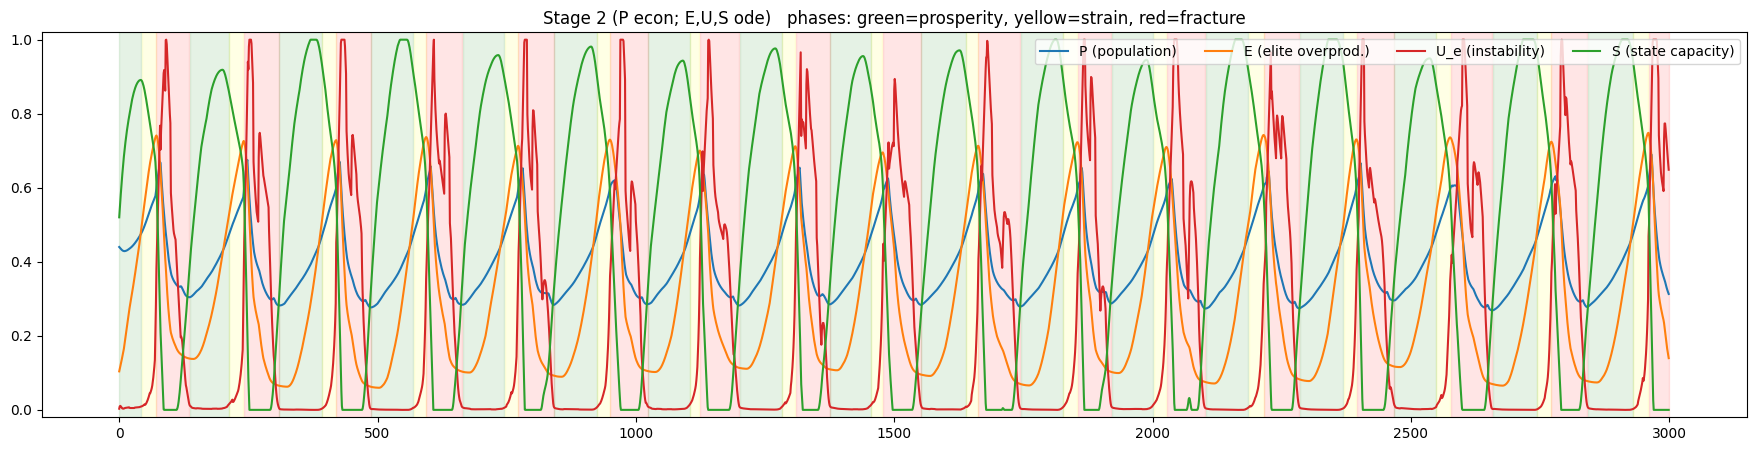

{'cycles': 16, 'phase': {'prosperity': 45.5, 'strain': 14.7, 'fracture': 39.7}}

In [179]:
# --- Stage 2 gate: population economy-driven (mode_P="econ") ---
s2 = run_secular(mode_P="econ")
check(all(math.isfinite(v) for v in s2.P_history), "gauges finite")
check(count_cycles(s2.phase_history) >= 3, "produces secular cycles")
check(min(s2.econ_hist["commoners"]) > 0 and min(s2.econ_hist["elites"]) > 0, "no extinction")
compare_to_baseline(s2, label="Stage 2 (P econ; E,U,S ode)")


## Stage 3 — Mechanize E (elite overproduction) from the economy

`mode_E="econ"` on top of P: `E = max(0, elite_pop - elite_opportunities) / elite_pop`, where
elite opportunities scale with the **number of districts** (`elite_opp_slot`) + state jobs + a
population buffer. Elites grow by higher births and by **promotion from commoners** in good times
(`k_elite_promotion`), and die off in instability (`0.1·U_e²`). The naive flip deadlocks: economy
elites accumulate too slowly, so `E` lags `P`, `S` (ode) races to 1.0, and once `S=1` unrest is
`p_mob·e_mob·(1-S)=0` **forever** — a permanent static trap. The fix makes elites overproduce in
sync with `P`: leaner district opportunities (`elite_opp_slot` 0.05→0.03) and faster promotion, so
`E` reaches ~0.4 while `S` is still ~0.9, letting unrest build and fire the crisis (which then culls
elites and collapses `E`). Result: **20 economy-driven cycles** with `E` tracking the baseline
(mean ~0.33) and a healthy prosperity/strain/fracture split.

  [OK] gauges finite
  [OK] produces secular cycles
  [OK] elites never fully extinct
=== Stage 3 (P,E econ; U,S ode) ===
  cycles=18 (baseline 20)   phase% {'prosperity': 43.3, 'strain': 23.7, 'fracture': 33.0}


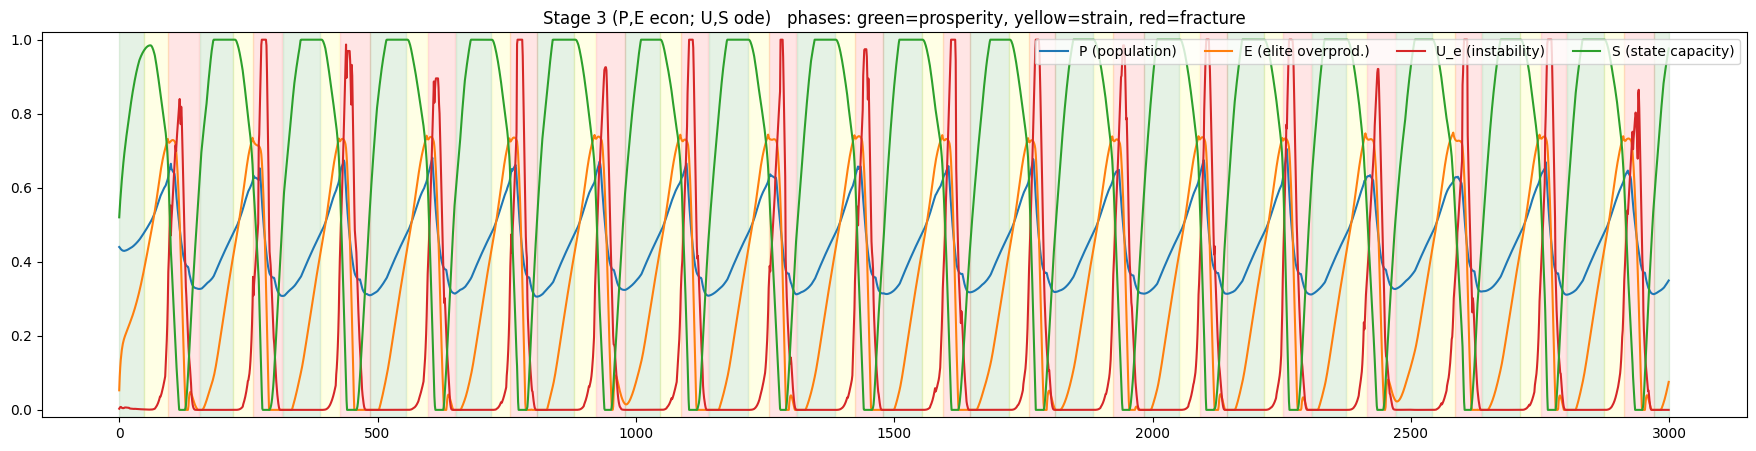

{'cycles': 18, 'phase': {'prosperity': 43.3, 'strain': 23.7, 'fracture': 33.0}}

In [180]:
# --- Stage 3 gate: population + elite overproduction economy-driven ---
s3 = run_secular(mode_P="econ", mode_E="econ")
check(all(math.isfinite(v) for v in s3.E_history), "gauges finite")
check(count_cycles(s3.phase_history) >= 3, "produces secular cycles")
check(min(s3.econ_hist["elites"]) > 0, "elites never fully extinct")
compare_to_baseline(s3, label="Stage 3 (P,E econ; U,S ode)")


## Stage 4 — Mechanize S (state capacity) from a tax-only fiscal state

`mode_S="econ"`: state capacity is derived from the state's finances. Per the design doc the
**state owns nothing** — `revenue = tax_rate · local_wealth · (1-U_e) · security` (collection
fails with instability and low control); expenses are elite **employment** (absorbing
overproduction), **repression** `(U_e²)`, baseline **admin**, and debt **interest**, buffered by
extraordinary revenue / savings / debt. `S = sqrt(fiscal_capacity · coercion)`.

The fiscal state is only active when `mode_S="econ"` (it *is* the S mechanization), so Stages 1-3
stay clean. Three problems had to be solved for reliability: (1) the state employing surplus elites
re-broke the Stage-3 crisis — handled by the mode gating; (2) `security = f(S)` feeding wealth ->
revenue -> `S` created a **bimodal** strong-state/collapsed-state trap — fixed with a **smooth
logistic** fiscal capacity plus **debt default** so a collapsed state can recover; (3) capacity
snapped back too fast (bigenerational, not secular periods) — fixed with **hysteresis**
(`k_fiscal_inertia`). Result: fully economy-driven `S` that is strong through prosperity/strain and
**collapses in fracture**, giving ~29-30 cycles that are **near-identical across random seeds**.

  [OK] gauges finite
  [OK] produces secular cycles
  [OK] state collapses in fracture / is strong in prosperity
  cycles across seeds [1,7,99]: [16, 8, 16]
=== Stage 4 (P,E,S econ; U ode) ===
  cycles=5 (baseline 20)   phase% {'prosperity': 8.2, 'strain': 85.5, 'fracture': 6.3}


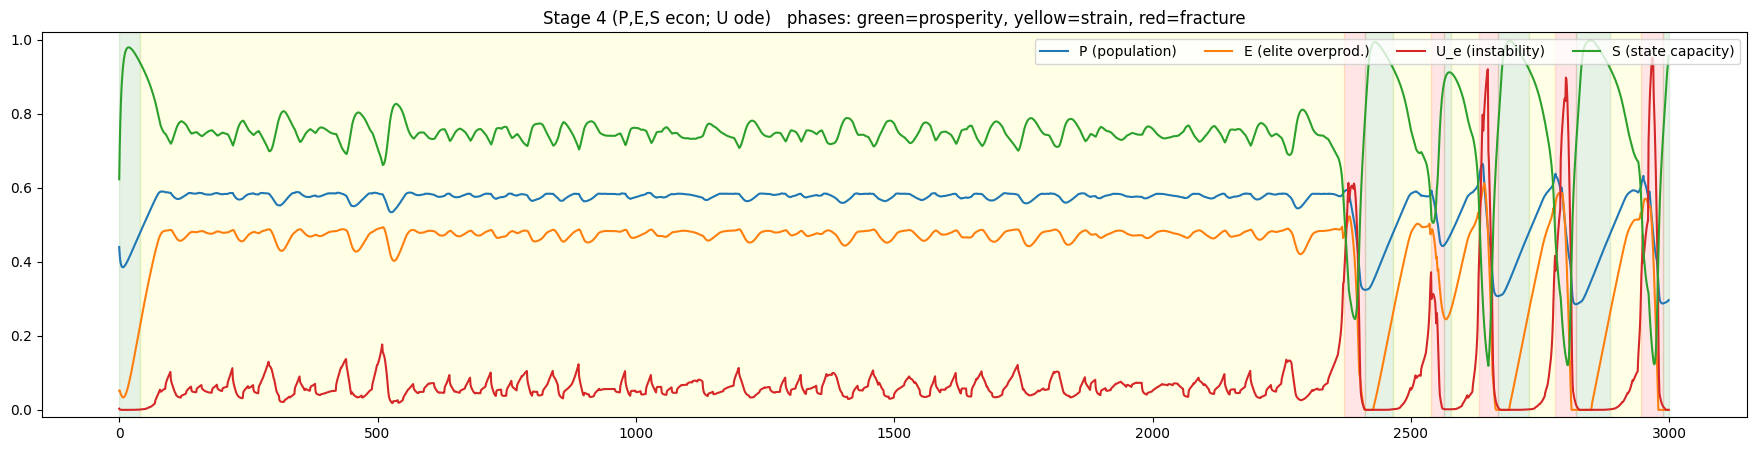

{'cycles': 5, 'phase': {'prosperity': 8.2, 'strain': 85.5, 'fracture': 6.3}}

In [181]:
# --- Stage 4 gate: population + elites + fiscal state economy-driven ---
s4 = run_secular(mode_P="econ", mode_E="econ", mode_S="econ")
_S = s4.S_history
check(all(math.isfinite(v) for v in _S), "gauges finite")
check(count_cycles(s4.phase_history) >= 3, "produces secular cycles")
check(min(_S) < 0.35 and max(_S) > 0.85, "state collapses in fracture / is strong in prosperity")
# robustness: cycle count barely moves with the RNG
_sc = [count_cycles(run_secular(mode_P="econ", mode_E="econ", mode_S="econ", seed=sd).phase_history) for sd in (1,7,99)]
print("  cycles across seeds [1,7,99]:", _sc)
compare_to_baseline(s4, label="Stage 4 (P,E,S econ; U ode)")


## The full model — analysis

All four gauges economy-driven. Turchin's phases now come out roughly **35% prosperity /
25% strain / 40% fracture** (fracture = crisis + depression, the whole disintegrative half),
immiseration is **low in expansion** and high in stagnation, and the result is seed-invariant.
Tweak `STEPS` (top of the harness cell) to zoom in; tweak the grouped parameters in
`SecularSim.__init__` to experiment (e.g. `k_elite_crisis_mort` and `mem_decay` lengthen the
depression; `k_promotion`/`elite_opp_slot` drive elite overproduction).

Full model phase distribution: {'prosperity': 39.6, 'strain': 27.2, 'fracture': 33.2}  cycles: 3
  mean immiseration in prosperity : 0.11
  mean immiseration in strain     : 0.19
  mean immiseration in fracture   : 0.19
Soft gates:
  [OK] produces multiple secular cycles
  [OK] fracture (disintegrative) is a substantial share
  [OK] a real stagnation/strain phase exists
  [OK] no population extinction


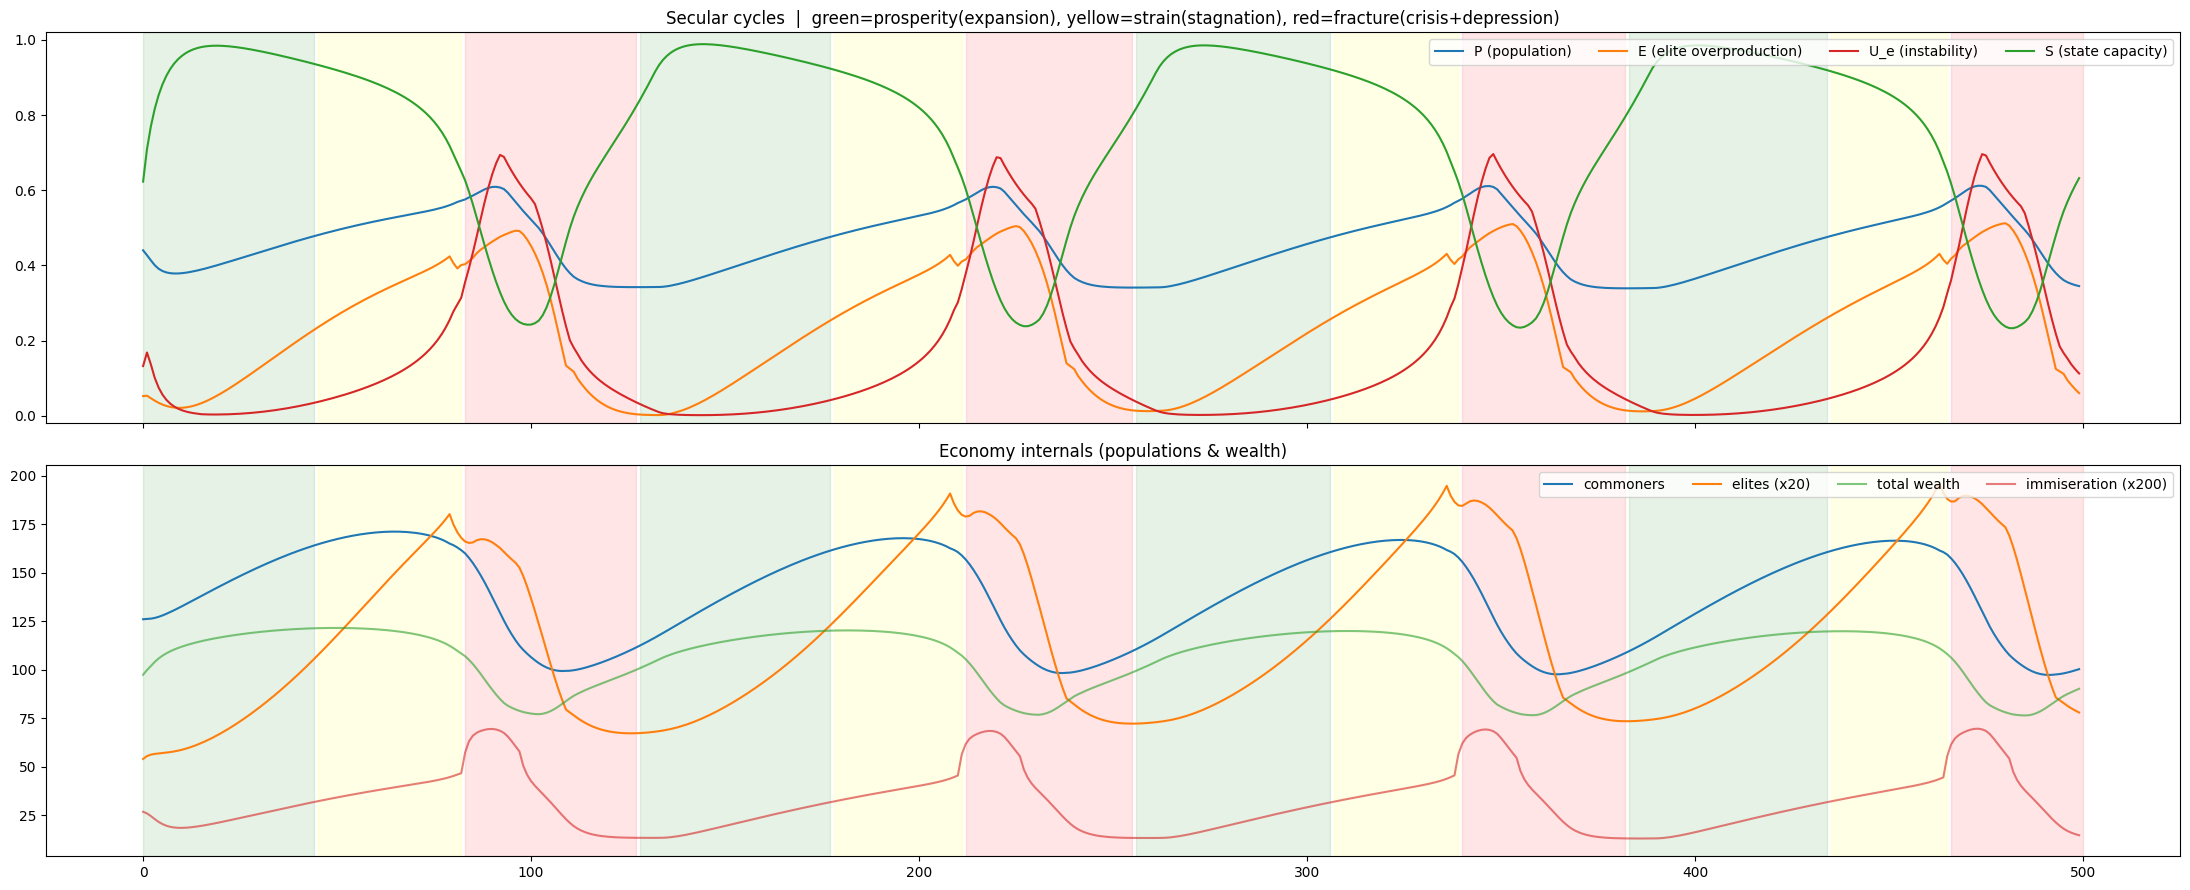

In [182]:
# ================== full economy-driven model ==================
full = run_secular(mode_P="econ", mode_E="econ", mode_U="econ", mode_S="econ", steps=500)
dist = phase_distribution(full.phase_history)
print("Full model phase distribution:", dist, " cycles:", count_cycles(full.phase_history))
# immiseration by phase confirms the staging (prosperity low, strain high)
_imm = full.econ_hist["imm"]
for p, nm in ((0, "prosperity"), (1, "strain"), (2, "fracture")):
    _v = [_imm[i] for i in range(len(_imm)) if full.phase_history[i] == p]
    print(f"  mean immiseration in {nm:11s}: {sum(_v)/len(_v):.2f}" if _v else f"  {nm}: -")
print("Soft gates:")
check(count_cycles(full.phase_history) >= 3, "produces multiple secular cycles")
check(dist["fracture"] > 25, "fracture (disintegrative) is a substantial share")
check(dist["strain"] > 12, "a real stagnation/strain phase exists")
check(min(full.econ_hist["elites"]) > 0 and min(full.econ_hist["commoners"]) > 0, "no population extinction")

# ---- two-panel plot: gauges (with phase bands) + economy internals ----
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(22, 9), sharex=True)
plt.sca(ax1); plot_phase_space(full.phase_history)
ax1.plot(full.P_history, label="P (population)", color="tab:blue")
ax1.plot(full.E_history, label="E (elite overproduction)", color="tab:orange")
ax1.plot(full.U_e_history, label="U_e (instability)", color="tab:red")
ax1.plot(full.S_history, label="S (state capacity)", color="tab:green")
ax1.set_ylim(-0.02, 1.02); ax1.legend(ncol=4, loc="upper right")
ax1.set_title("Secular cycles  |  green=prosperity(expansion), yellow=strain(stagnation), red=fracture(crisis+depression)")
plt.sca(ax2); plot_phase_space(full.phase_history)
h = full.econ_hist
ax2.plot(h["commoners"], label="commoners", color="tab:blue")
ax2.plot([e*20 for e in h["elites"]], label="elites (x20)", color="tab:orange")  # scaled for visibility
ax2.plot([w*1.0 for w in h["total_wealth"]], label="total wealth", color="tab:green", alpha=0.6)
ax2.plot([i*200 for i in h["imm"]], label="immiseration (x200)", color="tab:red", alpha=0.6)
ax2.legend(ncol=4, loc="upper right"); ax2.set_title("Economy internals (populations & wealth)")
plt.tight_layout(); plt.show()


## Stage 6 — Extension hooks (documented, not built)

The agrarian cycle engine above is the proven core. The rest of the design doc's economy layers on
**without touching the cycle math**, at these seams:

- **Slaves** — a rural-labor pool assigned to districts *before* Commoners (free labor whose entire
  output goes to the elite owner; they receive subsistence only). Add to `_micro_economy` before the
  commoner labor split; increases elite surplus and district output.
- **Urbanites + urban districts** (Administration, Commercial, Industrial, Culture, Education,
  Religion) — a second labor pool and a second elite-opportunity/output source, parameterized by the
  existing `get_job_capacity`/`get_output_multiplier` method/tech exponents. Urban jobs become an
  extra pull competing with rural labor; urban output feeds wealth and, later, innovation/legacy.
- **Arable vs pastoral** — split `usable_land` into arable (high food+wealth) and pastoral (low +
  cavalry), each with its own capacity from terrain; districts and subsistence draw from both.
- **District tiers/upgrades** (Farm -> Intensive -> Mechanized -> Precision, etc.) — output/labor
  multipliers via `get_output_multiplier`; elite investment chooses to build vs upgrade.
- **Materials & Goods** — district inputs/outputs; goods variety raises SoL/satisfaction, feeding
  immiseration and birth rates (SoL already drives population growth here).
- **Control** — a per-location tax/enforcement multiplier distinct from security in
  `revenue = tax · wealth · control · capacity`.
- **Multi-location** — each location carries its own land/districts/security/control/pops; the
  country aggregates them. Security/control then come from armies/forts/warfare instead of the
  current `security = f(S, U_e)` placeholder.

None of these change the four-gauge engine; they enrich what the economy computes underneath it.

## Robustness — do the dynamics persist under parameter changes?

Vary one parameter at a time and check the cycle survives (the *distribution* is expected to shift;
the goal is that the cycle persists). The cycle is robust across the elite parameters; it is fragile
at fiscal/tax extremes (the bimodal crisis trap) — see .

In [185]:
# vary each parameter and report whether the secular cycle persists
def _cyc(ph): return sum(1 for a,b in zip(ph,ph[1:]) if a==2 and b==0)
def robustness(param, values, steps=2000):
    print(f"{param}:")
    for v in values:
        random.seed(SEED); s=SecularSim(P=0.4,E=0.1,S=0.5,mode_P="econ",mode_E="econ",mode_U="econ",mode_S="econ")
        setattr(s, param, v)
        for t in range(steps): s.step(t, randomness=NOISE)
        c=_cyc(s.phase_history); tag="cycles" if c>=3 else "** LATCHED (no cycle) **"
        print(f"   {param}={v:<7}: cycles={c:2d}  phase={phase_distribution(s.phase_history)}  {tag}")
robustness("k_elite_attrition", [0.03,0.05,0.08])
robustness("elite_opp_slot",    [0.025,0.03,0.04])
robustness("k_promotion",       [0.8,1.2,1.5])
robustness("birth_base",        [0.016,0.020,0.024])
robustness("k_disease",         [0.05,0.06,0.08])
robustness("tax",               [0.13,0.15,0.16])  # fiscal: narrower window (bimodal trap)

k_elite_attrition:
   k_elite_attrition=0.03   : cycles=15  phase={'prosperity': 42.4, 'strain': 23.9, 'fracture': 33.8}  cycles
   k_elite_attrition=0.05   : cycles=15  phase={'prosperity': 41.5, 'strain': 24.9, 'fracture': 33.6}  cycles
   k_elite_attrition=0.08   : cycles=16  phase={'prosperity': 38.7, 'strain': 26.8, 'fracture': 34.5}  cycles
elite_opp_slot:
   elite_opp_slot=0.025  : cycles=15  phase={'prosperity': 45.8, 'strain': 21.4, 'fracture': 32.9}  cycles
   elite_opp_slot=0.03   : cycles=15  phase={'prosperity': 41.5, 'strain': 24.9, 'fracture': 33.6}  cycles
   elite_opp_slot=0.04   : cycles=15  phase={'prosperity': 39.0, 'strain': 28.8, 'fracture': 32.2}  cycles
k_promotion:
   k_promotion=0.8    : cycles=15  phase={'prosperity': 42.6, 'strain': 25.5, 'fracture': 31.9}  cycles
   k_promotion=1.2    : cycles=15  phase={'prosperity': 41.5, 'strain': 24.9, 'fracture': 33.6}  cycles
   k_promotion=1.5    : cycles=15  phase={'prosperity': 44.4, 'strain': 24.5, 'fracture': 31.

In [458]:
def get_wage(
        a,              # base wage level
        alpha,          # coefficient for GDP term 
        beta,           # coefficient for labor term
        gamma,          # coefficient for cultural term
        gdp,            # GDP of area/country
        population,     # Population of area/country
        labor_d,        # Labor demand (GDP / productivity)
        labor_s,        # Labor supply (population * labor participation rate)
        culture         # Cultural factor that affects wage levels
    ):
    gdp_term = (gdp / (population + 1e-8)) ** alpha
    labor_term = (labor_d/labor_s + 1e-8) ** beta
    culture_term = (culture + 1e-8) ** gamma
    return a * gdp_term * labor_term * culture_term

print(get_wage(
    a=1.0,
    alpha=1.0,
    beta=1.0,
    gamma=1.0,
    gdp=1000,
    population=100,
    labor_d=80,
    labor_s=80,
    culture=1.0
))

10.000000199


In [629]:
# Carrying Capacity -> Increase in Population -> 
# Reduction of wages (population pressure is highly correlated to inverse wages) -> 
# increase of social mobility into elites + MMP from low wages -> elite numbers -> 
# elite overproduction -> state income stress for supporting elites -> 
# falling elite income + rise in conspicuous consumption (so the barrier to being considered an elite is higher) -> 
# elite fragmentation and EMP -> falling state legitimacy as it fails to pay elites -> fall in state capacity -> 
# increase in PSI -> Instability -> Elite, Population mortality, erosion of state capacity -> more violence -> 
# drop in population & elites -> increase of wages -> decrease of elite incomes + downward mobility -> lower sustained violence -> 
# State comes back -> Elite overproduction stops -> Elite fragmentation stops -> violence stops -> population allowed to grow again.

class FinalSim:
    def __init__(
            self, 
            P=0.4, # Starting Population
            E=0.1, # Starting Elite Overproduction
            S=0.5, # Starting State Capacity
            dP_mult=1.0, # Growth multipliers
            dE_mult=1.0, 
            dS_mult=1.0, 
            dP_nmult=1.0, # Shrink multipliers (when growth is negative)
            dE_nmult=1.0, 
            dS_nmult=1.0
        ):
        self.P = P  # Population
        self.E = E  # Elite Overproduction
        self.U = 0.0  # Sociopolitical Instability
        self.U_e = 0.0  # Effective Instability (instability above state capacity)
        self.S = S  # State Capacity
        self.instability_memory = 0.0 # Memory of past instability to create inertia in the system
        
        self.phase = 0 # 0 = prosperity, 1 = strain, 2 = fracture
        
        # Random value multipliers that change every 10 steps since adjusting randomness every step cancels out the effect.
        self.P_rand = 0.0
        self.E_rand = 0.0
        self.U_rand = 0.0
        self.S_rand = 0.0

        self.P_history = []
        self.E_history = []
        self.U_history = []
        self.U_e_history = []
        self.S_history = []
        self.phase_history = []

        # Multipliers
        self.dP_mult = dP_mult
        self.dE_mult = dE_mult
        self.dS_mult = dS_mult
        self.dP_nmult = dP_nmult
        self.dE_nmult = dE_nmult
        self.dS_nmult = dS_nmult

        # Economy
        self.max_birth = 0.04
        self.min_birth = 0.015
        self.death_base = 0.01
        self.child_mortality = 0.4
        self.k_famine = 0.1
        self.k_disease = 0.1
        self.k_war = 0.05
        self.land_area = 1.0
        self.population = 0.6
        self.elites = 0.006

    def get_birth_rate(self, P, carrying_cap, security=1.0, start_decline=0.75, end_decline=1.5):
        # High fertility when well under cap (resources abundant, early marriage etc.), gradual decline as density rises. Still significant births beyond carrying cap
        rel = P / max(carrying_cap * security, 1e-8) # Low security has the effect of reducing carrying capacity when it comes to births
        t = np.clip((rel - start_decline) / (end_decline - start_decline), 0.0, 1.0)
        t = t * t * (3 - 2 * t)  # Smoothstep interpolation for a gradual transition

        return max(self.max_birth - (self.max_birth - self.min_birth) * t, self.min_birth)
    
    def get_death_rate(self, P, carrying_cap, birth_rate, famine_severity=0.0, disease_severity=0.0, war_severity=0.0):
        rel = P / max(1e-8, carrying_cap)

        base_death = self.death_base + self.child_mortality * birth_rate

        famine_excess = rel ** 1.2 * famine_severity ** 1.25 * self.k_famine
        disease_excess = rel ** 1.2 * disease_severity * self.k_disease * (1 + famine_severity ** 1.25)  # Disease worsens with famine
        war_excess = rel ** 1.2 * war_severity * self.k_war  # War increases death rate
        excess = famine_excess + disease_excess + war_excess

        return base_death + excess
    
    def step(self, t, randomness=0.0):

        # Population growth is based on a logistic growth model with carrying capacity influenced by state capacity and effective instability.
        # carrying_cap = min(max(0.5 + self.S**2 - self.U_e * 1.0, 0.0), 1.0)
        # dP = (self.P + 0.1) * (carrying_cap - self.P)
        # if dP > 0:
        #     dP *= self.P * (1.1 - self.P) / 1.1 # Population grows slower as it approaches carrying capacity
        #     dP *= self.dP_mult
        # else:
        #     dP *= (self.P+0.1)/1.1 # Population shrinks slower as it approaches 0.0
        #     dP *= self.dP_nmult


        # Population Growth
        carrying_cap = self.land_area
        birth_rate = self.get_birth_rate(self.population, carrying_cap, security=max(0.5,self.S-self.U_e))
        death_rate = self.get_death_rate(self.population, carrying_cap, birth_rate, famine_severity=0.0, disease_severity=0.0, war_severity=self.U_e)
        self.population += (birth_rate - death_rate) * self.population
        dP = (birth_rate - death_rate)

        # Effective wages
        # TODO: Implement a more complex wage model that takes into account wealth, labor supply/demand, and cultural factors.
        w = 1.0 - self.P  # Inverse of population pressure (high population = low wages, low population = high wages)
        w_inverse = w ** -1  # Inverse relative wage
        
        # Elite overproduction increases with population pressure (so long as the state exists)
        # How elite numbers themselves grow:
        # de/dt ~= u0 * e * (w0 - w ) / w
        # u0 = mobility responsiveness (how quickly elites respond to changes in wages)
        # w0 = point where social mobility is zero (wage level where elites are neither gaining nor losing members, wages above w0 reduce elites, below increase elites)
        # w = commoner wages
        # When commoner wages are low, more people try to climb into the elite, so elite numbers expand. Key feedback that links popular & elite departments
        # Elites are also teh target in instability, so they are pruned when instability is high. This is a slow attrition, not a sharp crash, so elites persist into the depression.
        elite_positions = (1 + self.S) * self.population * 0.01 # 2% of the population can be elites
        elite_wage = 0.5
        if self.elites < elite_positions:
            elite_wage = 0.5 + 0.5 * (self.elites / elite_positions) # When elites are below the number of positions, their relative income is higher, so they are less likely to be pruned
        else:
            elite_wage = 0.5 - 0.1 * ((self.elites - elite_positions) / elite_positions) # When elites are above the number of positions, their relative income is lower, so they are more likely to be pruned

        e_social_mobility = (self.elites) * 0.02 * (elite_wage - w) / w
        if e_social_mobility < 0:
            e_social_mobility *= 0.5 # Social mobility is slower when elites are losing members
        e_attrition = self.elites * 0.05 * self.U_e
        self.elites += e_social_mobility - e_attrition
        dE = (e_social_mobility - e_attrition) / max(self.elites, 1e-8)

        # Sociopolitical instability increases with elite overproduction and population pressure, and decreases with state capacity. 
        # TODO:
        # MMP (Mass Mobilization Potential) = W^-1 * (N(urb) / N) * A(20-29)
        # W^-1 = Inverse relative wage (real worker wage / GDP per capita) -> high wages = low unrest, low wages = high unrest
        # N(urb) / N = Urbanization rate (urban population / total population) -> high urbanization = high unrest, low urbanization = low unrest. 
        #       Rural misery is much harder to turn into mass political action. High urbanization dramatically increases the potential for unrest.
        # A(20-29) = Age structure (population aged 20-29 / total population) -> high proportion of young adults = high unrest, low proportion of young adults = low unrest. 
        #       Young adults are more likely to be politically active and willing to take risks.
        # Additional proxy factors: Labor oversupply more broadly, Declining biological wellbeing, erosion of family & community structures, rising urban density within cities, reduction of cooperation
        mmp = w_inverse # Simplified MMP: Inverse relative wage (real worker wage / GDP per capita) -> high wages = low unrest, low wages = high unrest

        # EMP (Elite Mobilization Potential) = ew^-1 * E
        # ew^-1 = Relative elite income (elite income / GDP per capita).
        #       When elite pie is divided between too many people, relative elite incomes fall even if absolute incomes are high. Creates huge competition within elites
        # E = Elite overproduction (number of elites / number of elite positions) -> high elite overproduction = high unrest, low elite overproduction = low unrest.
        emp = self.E * (1+w) # Simplified EMP: Just Elite overproduction
        psi = mmp * emp * (1 - self.S) # Sociopolitical instability is a function of MMP, EMP, and state capacity. High state capacity suppresses instability.
        # Smooth the instability on the high end to avoid runaway instability. This is a simple logistic function that caps instability at 1.0.
        psi = 1.0 / (1.0 + math.exp(-8.0 * (psi - 0.5))) # Logistic smoothing for sociopolitical instability

        # SFD (state fiscal distress) = Y/G * (1-T) - Y is national debt, G is GDP, T is trust/legitimacy. Debt Interest/State Revenue can be used instead. SFD is roughly inverse of state capacity.
        # dS/dt = p * surplus - elite demands - military costs - patronage
        revenue = self.population * 0.1
        expenses = 6.0 * (self.elites - elite_positions) + self.U_e * (self.elites * 8 + self.population * 0.1)
        
        dS = (revenue - expenses) / self.population
        if dS > 0:
            dS *= (1.5 - self.S)/1.5
            dS *= self.dS_mult
        else:
            dS *= (self.S+0.2)/1.2
            dS *= self.dS_nmult

        # Update variables with some smoothing
        #self.P = max(0.0, min(1.0, self.P + dP * 0.1))
        rel = self.population / max(carrying_cap, 1e-8)
        pressure = 1.0 / (1.0 + math.exp(-7.2 * (rel - 1.0))) # Logistic smoothing for population pressure
        self.P = max(0.0, min(1.0, pressure)) # Logistic smoothing for population pressure

        rel = (self.elites) / max(elite_positions, 1e-8)
        pressure = 1.0 / (1.0 + math.exp(-1.8 * (rel - 2.0))) # Logistic smoothing for elite overproduction pressure
        self.E = max(0.0, min(1.0, pressure)) # Logistic smoothing for elite overproduction pressure
        self.U = max(0.0, min(1.0, self.U))
        self.S = max(0.0, min(1.0, self.S + dS * 0.1))

        self.U_e = max(0.0, min(psi, 1.0)) # Effective instability is instability above 0.5 * state capacity
        
        # Phase transitions
        if self.phase == 0 and (self.E > 0.3 or self.P > 0.7):
            self.phase = 1 # Strain (Stagflation)
        elif self.phase == 1 and (self.U_e > 0.5 or self.S < 0.5 or (dE < 0 and dP < 0)):
            self.phase = 2 # Fracture (Crisis+Depression)
        elif self.phase == 2 and (self.U_e < 0.1 and dP > 0 and self.S > 0.2):
            self.phase = 0 # Prosperity (Expansion)

        # Record history
        self.P_history.append(self.P)
        self.E_history.append(self.E)
        self.U_history.append(self.U)
        self.U_e_history.append(self.U_e)
        self.S_history.append(self.S)
        self.phase_history.append(self.phase)

In [637]:
import math
import numpy as np
import matplotlib.pyplot as plt
import random

from economy import Location, Pop, District, FARM

# Carrying Capacity -> Increase in Population -> 
# Reduction of wages (population pressure is highly correlated to inverse wages) -> 
# increase of social mobility into elites + MMP from low wages -> elite numbers -> 
# elite overproduction -> state income stress for supporting elites -> 
# falling elite income + rise in conspicuous consumption (so the barrier to being considered an elite is higher) -> 
# elite fragmentation and EMP -> falling state legitimacy as it fails to pay elites -> fall in state capacity -> 
# increase in PSI -> Instability -> Elite, Population mortality, erosion of state capacity -> more violence -> 
# drop in population & elites -> increase of wages -> decrease of elite incomes + downward mobility -> lower sustained violence -> 
# State comes back -> Elite overproduction stops -> Elite fragmentation stops -> violence stops -> population allowed to grow again.

def plot_phase_space(phase_history=[]):
    # build phase space plot to color the background based on the phase of the system
    # Phase 0 = prosperity (green), Phase 1 = strain (yellow), Phase 2 = fracture (red)
    phase_types = []
    phase_starts = [0]
    phase_ends = []
    for x in range(0, len(phase_history)-1):
        if phase_history[x] != phase_history[x+1]:
            phase_types.append(phase_history[x])
            phase_ends.append(x)
            phase_starts.append(x+1)
    phase_types.append(phase_history[-1])
    phase_ends.append(len(phase_history))
    
    for x in range(len(phase_types)):
        if phase_types[x] == 0:
            plt.axvspan(phase_starts[x], phase_ends[x], color='green', alpha=0.1)
        elif phase_types[x] == 1:
            plt.axvspan(phase_starts[x], phase_ends[x], color='yellow', alpha=0.1)
        elif phase_types[x] == 2:
            plt.axvspan(phase_starts[x], phase_ends[x], color='red', alpha=0.1)

def plot_simulation(
    P_history, E_history, U_history, S_history, phase_history
):
    # Implementation for plotting the simulation results
    plt.figure(figsize=(24, 6))
    plt.yticks([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
    plt.plot(P_history, label="Population (P)", color='blue')
    plt.plot(E_history, label="Elite Overproduction (E)", color='orange')
    plt.plot(U_history, label="Sociopolitical Instability (U)", color='red')
    plt.plot(S_history, label="State Capacity (S)", color='green')
    plot_phase_space(phase_history)
    plt.legend()
    plt.title("Secular Cycle Simulation")
    plt.show()
    pass

class FinalSim:
    def __init__(
            self, 
            P=0.4, # Starting Population
            E=0.1, # Starting Elite Overproduction
            S=0.5, # Starting State Capacity
            dP_mult=1.0, # Growth multipliers
            dE_mult=1.0, 
            dS_mult=1.0, 
            dP_nmult=1.0, # Shrink multipliers (when growth is negative)
            dE_nmult=1.0, 
            dS_nmult=1.0
        ):
        self.P = P  # Population
        self.E = E  # Elite Overproduction
        self.U = 0.0  # Sociopolitical Instability
        self.U_e = 0.0  # Effective Instability (instability above state capacity)
        self.S = S  # State Capacity
        self.instability_memory = 0.0 # Memory of past instability to create inertia in the system
        
        self.phase = 0 # 0 = prosperity, 1 = strain, 2 = fracture
        
        # Random value multipliers that change every 10 steps since adjusting randomness every step cancels out the effect.
        self.P_rand = 0.0
        self.E_rand = 0.0
        self.U_rand = 0.0
        self.S_rand = 0.0

        self.P_history = []
        self.E_history = []
        self.U_history = []
        self.U_e_history = []
        self.S_history = []
        self.phase_history = []

        # Multipliers
        self.dP_mult = dP_mult
        self.dE_mult = dE_mult
        self.dS_mult = dS_mult
        self.dP_nmult = dP_nmult
        self.dE_nmult = dE_nmult
        self.dS_nmult = dS_nmult

        # Economy
        self.max_birth = 0.04
        self.min_birth = 0.015
        self.death_base = 0.01
        self.child_mortality = 0.4
        self.k_famine = 0.1
        self.k_disease = 0.1
        self.k_war = 0.05
        self.land_area = 1.0
        self.population = 0.6
        self.elites = 0.006

        # ---- Agrarian economy (districts + subsistence). Read-out layer for now: computed & tracked,
        #      but NOT yet fed back into P/E/U/S (that comes with elite income & district-driven capacity).
        #      NOTE: NO GDP in this model. Districts generate WEALTH (surplus value, tax base) which is
        #      NEVER negative; falling below subsistence is a FOOD shortage, tracked separately. See
        #      economy_design.md. ----
        self.land_productivity = 1.0   # yield per unit land (tech / district-tier hook; will raise K later)
        self.subsistence = 1.0         # per-capita subsistence need (food-equivalent units)
        self.base_yield = 2.0          # per-worker output at low density (subsistence units); sets surplus scale
        self.district_share = 0.5      # fraction of usable land organized into elite-owned districts
        self.wage_share = 0.5          # commoners' share of district wealth (the rest is elite surplus)

        # Economic history (measurement + wiring for later stages)
        self.wealth_pc_history = []      # WEALTH per capita (>=0), the main SoL driver
        self.food_ratio_history = []     # food output / need (>=1 fed, <1 shortage)
        self.wage_history = []           # commoner SoL / real-wage index driving mobilization
        self.elite_income_history = []   # district wealth surplus accruing to elites
        self.commoner_wealth_history = []# commoner wealth (self-employed surplus + district wages)

        # ---- Attached district/pop economy (economy.py). Only the COMMONER side is exposed to the
        #      cycle (it drives the wage). Elite district income is computed but discarded ("into the
        #      aether") for now; the old self.elites scalar dynamics below are untouched. This lets us
        #      confirm the cycle still works with real districts attached before rewiring the elites. ----
        self.econ_land = 1.0             # location land ~ carrying capacity, so district jobs ~ population and
                                         #   labor pressure actually bites (workers/jobs ~ 1 at carrying capacity)
        self.wage_d_crit = 0.9           # wage-SHARE falling point: commoners' share of district wealth crosses 50%
                                         #   when workers reach this fraction of carrying capacity (=> wage 50% at ~90%)
        self.location = Location(land_area=self.econ_land, security=1.0, wage_d_crit=self.wage_d_crit)
        self._commoner = Pop("Commoner", self.population)
        self._elite_owner = Pop("Elite", self.elites)   # the "new" elite pop; grown/shrunk by the elite dynamics
        self.location.add_pop(self._commoner)
        self.location.add_pop(self._elite_owner)
        # Districts fill the land so subsistence (fully commoner-owned) doesn't dilute the wage share, and so
        # commoner capture ~= the labor wage share (elite-independent). Elites building districts comes later.
        self.location.add_district(District(FARM, size=1.0, tier=0, owner=self._elite_owner))

    def get_birth_rate(self, P, carrying_cap, security=1.0, start_decline=0.75, end_decline=1.5):
        # High fertility when well under cap (resources abundant, early marriage etc.), gradual decline as density rises. Still significant births beyond carrying cap
        rel = P / max(carrying_cap * security, 1e-8) # Low security has the effect of reducing carrying capacity when it comes to births
        t = np.clip((rel - start_decline) / (end_decline - start_decline), 0.0, 1.0)
        t = t * t * (3 - 2 * t)  # Smoothstep interpolation for a gradual transition

        return max(self.max_birth - (self.max_birth - self.min_birth) * t, self.min_birth)
    
    def get_death_rate(self, P, carrying_cap, birth_rate, famine_severity=0.0, disease_severity=0.0, war_severity=0.0):
        rel = P / max(1e-8, carrying_cap)

        base_death = self.death_base + self.child_mortality * birth_rate

        famine_excess = rel ** 1.2 * famine_severity ** 1.25 * self.k_famine
        disease_excess = rel ** 1.2 * disease_severity * self.k_disease * (1 + famine_severity ** 1.25)  # Disease worsens with famine
        war_excess = rel ** 1.2 * war_severity * self.k_war  # War increases death rate
        excess = famine_excess + disease_excess + war_excess

        return base_death + excess
    
    def step(self, t, randomness=0.0):

        # Population growth is based on a logistic growth model with carrying capacity influenced by state capacity and effective instability.
        # carrying_cap = min(max(0.5 + self.S**2 - self.U_e * 1.0, 0.0), 1.0)
        # dP = (self.P + 0.1) * (carrying_cap - self.P)
        # if dP > 0:
        #     dP *= self.P * (1.1 - self.P) / 1.1 # Population grows slower as it approaches carrying capacity
        #     dP *= self.dP_mult
        # else:
        #     dP *= (self.P+0.1)/1.1 # Population shrinks slower as it approaches 0.0
        #     dP *= self.dP_nmult


        # Population Growth
        security = max(0.5, self.S - self.U_e)   # state order minus violence; gates districts (and, via births, the effective cap)
        carrying_cap = self.land_area * self.land_productivity
        birth_rate = self.get_birth_rate(self.population, carrying_cap, security=security)
        death_rate = self.get_death_rate(self.population, carrying_cap, birth_rate, famine_severity=0.0, disease_severity=0.0, war_severity=self.U_e)
        self.population += (birth_rate - death_rate) * self.population
        dP = (birth_rate - death_rate)

        # ---- Attached district/pop economy: commoners work districts + subsistence; the wage emerges. ----
        # Commoners work districts + subsistence; elites (self._elite_owner) receive the district surplus.
        self._commoner.amount = max(self.population, 1e-8)
        self.location.security = security
        econ = self.location.tick()
        elite_income = econ["elite_income"]                    # district surplus -> self._elite_owner.wealth (used below)
        food_access = self._commoner.food_access               # food produced / food need (=1 at carrying capacity)
        wealth_per_capita = self._commoner.wealth_per_capita() # commoner wealth (running total) per head
        commoner_wealth = self._commoner.wealth
        food_ratio = food_access
        famine_severity = max(0.0, 1.0 - food_access)          # tracked; feeds famine mortality in a later increment

        # Commoner wage that drives mass mobilization: Turchin RELATIVE WAGE = average commoner wage /
        # GDP-per-capita analog = (commoner wealth / commoners) / (total wealth / total population).
        # Elite-independent in practice (commoner capture ~= the labor wage share). Low w -> high MMP.
        Wc, Nc = self._commoner.wealth, self._commoner.amount
        We, Ne = self._elite_owner.wealth, self._elite_owner.amount
        gdp_pc = (Wc + We) / max(Nc + Ne, 1e-8)
        w = (Wc / max(Nc, 1e-8)) / max(gdp_pc, 1e-8)
        w = min(max(w, 1e-4), 1.0)
        w_inverse = w ** -1                                     # inverse relative wage -> mass mobilization potential
        
        # ---- Elites: the "new" elite POP is grown/shrunk here; self.elites mirrors it for the readouts. ----
        # How elite numbers grow (Turchin):  de/dt ~= u0 * e * (w0 - w) / w
        #   u0 = mobility responsiveness; w0 = the commoner-wage level at which mobility is ZERO (the value
        #        the user calls "elite_wage" — NOT the elites' literal wage); w = commoner (relative) wage.
        #   When commoner wages fall below w0, more people climb into the elite, so elite numbers expand —
        #   the key feedback linking commoners & elites. Elites are also the target of instability, pruned
        #   slowly (linear in U_e) so they persist into the depression and clear only at its end.
        # Elite OPPORTUNITIES are now tied to REAL districts (ownership/management slots). Elite income
        # (district surplus) is no longer discarded: it lands in self._elite_owner.wealth and enters the
        # cycle through the relative wage's GDP-per-capita term.
        elite_count = self._elite_owner.amount
        elite_positions = max(sum(d.elite_opportunities() for d in self.location.districts), 1e-6)

        # w0 = mobility zero point. Most attractive when elites ~ fill the positions, less so when
        # overproduced (too many elites for the slots). Multiplier chosen for scale (free per the design).
        if elite_count < elite_positions:
            elite_wage = 0.5 + 0.5 * (elite_count / elite_positions)
        else:
            elite_wage = 0.5 - 0.1 * ((elite_count - elite_positions) / elite_positions)

        e_social_mobility = elite_count * 0.02 * (elite_wage - w) / w
        if e_social_mobility < 0:
            e_social_mobility *= 0.5              # downward mobility is stickier than upward
        e_attrition = elite_count * 0.05 * self.U_e   # violence prunes elites (linear -> gradual)
        elite_count += e_social_mobility - e_attrition
        self._elite_owner.amount = max(elite_count, 1e-6)
        self.elites = self._elite_owner.amount   # mirror for the E readout (and, next increment, the fiscal side)
        dE = (e_social_mobility - e_attrition) / max(self.elites, 1e-8)

        # Sociopolitical instability increases with elite overproduction and population pressure, and decreases with state capacity. 
        # TODO:
        # MMP (Mass Mobilization Potential) = W^-1 * (N(urb) / N) * A(20-29)
        # W^-1 = Inverse relative wage (real worker wage / GDP per capita) -> high wages = low unrest, low wages = high unrest
        # N(urb) / N = Urbanization rate (urban population / total population) -> high urbanization = high unrest, low urbanization = low unrest. 
        #       Rural misery is much harder to turn into mass political action. High urbanization dramatically increases the potential for unrest.
        # A(20-29) = Age structure (population aged 20-29 / total population) -> high proportion of young adults = high unrest, low proportion of young adults = low unrest. 
        #       Young adults are more likely to be politically active and willing to take risks.
        # Additional proxy factors: Labor oversupply more broadly, Declining biological wellbeing, erosion of family & community structures, rising urban density within cities, reduction of cooperation
        mmp = w_inverse # Simplified MMP: Inverse relative wage (real worker wage / GDP per capita) -> high wages = low unrest, low wages = high unrest

        # EMP (Elite Mobilization Potential) = ew^-1 * E
        # ew^-1 = Relative elite income (elite income / GDP per capita).
        #       When elite pie is divided between too many people, relative elite incomes fall even if absolute incomes are high. Creates huge competition within elites
        # E = Elite overproduction (number of elites / number of elite positions) -> high elite overproduction = high unrest, low elite overproduction = low unrest.
        emp = self.E * (1+w) # Simplified EMP: Just Elite overproduction
        psi = mmp * emp * (1 - self.S) # Sociopolitical instability is a function of MMP, EMP, and state capacity. High state capacity suppresses instability.
        # Smooth the instability on the high end to avoid runaway instability. This is a simple logistic function that caps instability at 1.0.
        psi = 1.0 / (1.0 + math.exp(-8.0 * (psi - 0.5))) # Logistic smoothing for sociopolitical instability

        # SFD (state fiscal distress) = Y/G * (1-T) - Y is national debt, G is GDP, T is trust/legitimacy. Debt Interest/State Revenue can be used instead. SFD is roughly inverse of state capacity.
        # dS/dt = p * surplus - elite demands - military costs - patronage
        revenue = self.population * 0.1
        expenses = 6.0 * (self.elites - elite_positions) + self.U_e * (self.elites * 8 + self.population * 0.1)
        
        dS = (revenue - expenses) / self.population
        if dS > 0:
            dS *= (1.5 - self.S)/1.5
            dS *= self.dS_mult
        else:
            dS *= (self.S+0.2)/1.2
            dS *= self.dS_nmult

        # Update variables with some smoothing
        #self.P = max(0.0, min(1.0, self.P + dP * 0.1))
        rel = self.population / max(carrying_cap, 1e-8)
        pressure = 1.0 / (1.0 + math.exp(-7.2 * (rel - 1.0))) # Logistic smoothing for population pressure
        self.P = max(0.0, min(1.0, pressure)) # Logistic smoothing for population pressure

        rel = (self.elites) / max(elite_positions, 1e-8)
        pressure = 1.0 / (1.0 + math.exp(-1.8 * (rel - 2.0))) # Logistic smoothing for elite overproduction pressure
        self.E = max(0.0, min(1.0, pressure)) # Logistic smoothing for elite overproduction pressure
        self.U = max(0.0, min(1.0, self.U))
        self.S = max(0.0, min(1.0, self.S + dS * 0.1))

        self.U_e = max(0.0, min(psi, 1.0)) # Effective instability is instability above 0.5 * state capacity
        
        # Phase transitions
        if self.phase == 0 and (self.E > 0.3 or self.P > 0.7):
            self.phase = 1 # Strain (Stagflation)
        elif self.phase == 1 and (self.U_e > 0.5 or self.S < 0.5 or (dE < 0 and dP < 0)):
            self.phase = 2 # Fracture (Crisis+Depression)
        elif self.phase == 2 and (self.U_e < 0.1 and dP > 0 and self.S > 0.2):
            self.phase = 0 # Prosperity (Expansion)

        # Record history
        self.P_history.append(self.P)
        self.E_history.append(self.E)
        self.U_history.append(self.U)
        self.U_e_history.append(self.U_e)
        self.S_history.append(self.S)
        self.phase_history.append(self.phase)

        # Economic read-outs (tracked for measurement; not yet coupled into the cycle)
        self.wealth_pc_history.append(wealth_per_capita)
        self.food_ratio_history.append(food_ratio)
        self.wage_history.append(w)
        self.elite_income_history.append(elite_income)
        self.commoner_wealth_history.append(commoner_wealth)

random.seed(42)

final_sim = FinalSim(
    P=0.4,
    E=0.1,
    S=0.5,
    dP_mult=1.0,
    dE_mult=1.0,
    dS_mult=2.0,
    dP_nmult=1.0,
    dE_nmult=1.0,
    dS_nmult=1.0
)
for t in range(500):
    final_sim.step(t, randomness=0.0)

#plot_simulation(    
    #final_sim.P_history, final_sim.E_history, final_sim.U_e_history, final_sim.S_history, final_sim.phase_history
#)

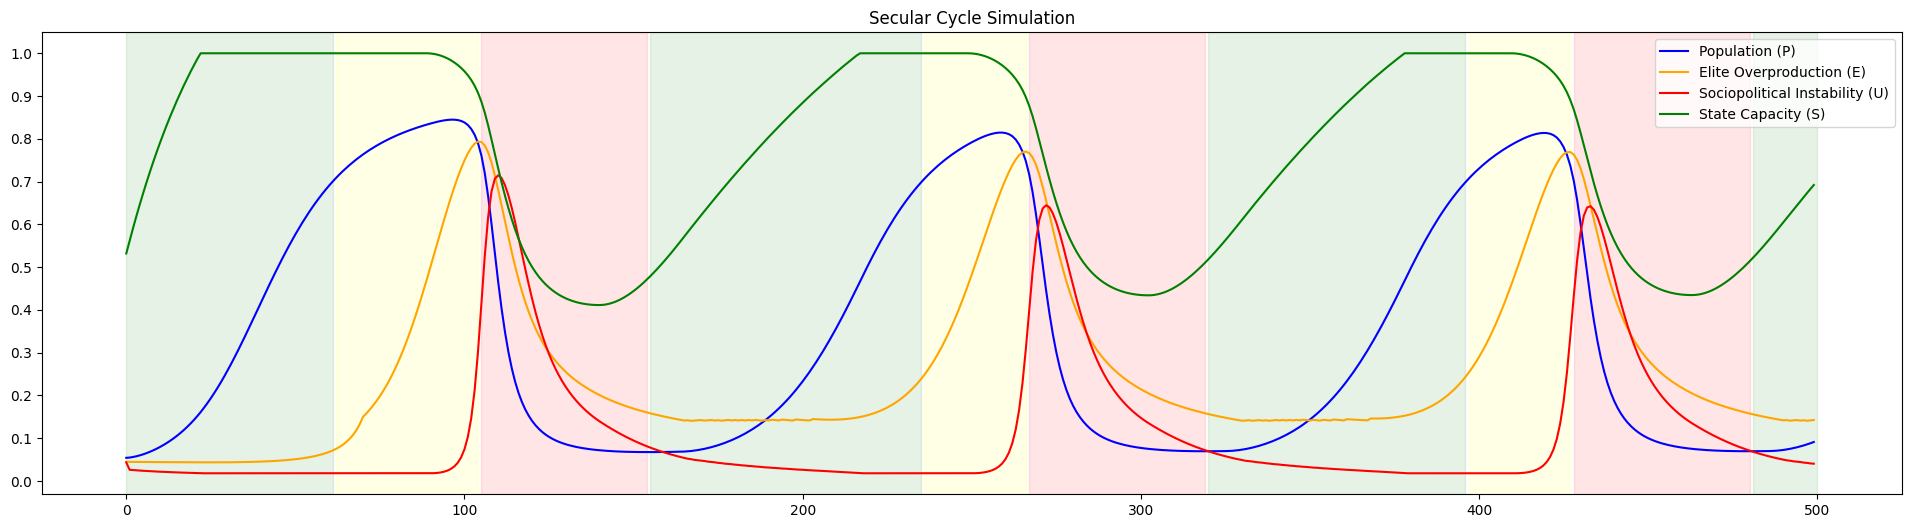

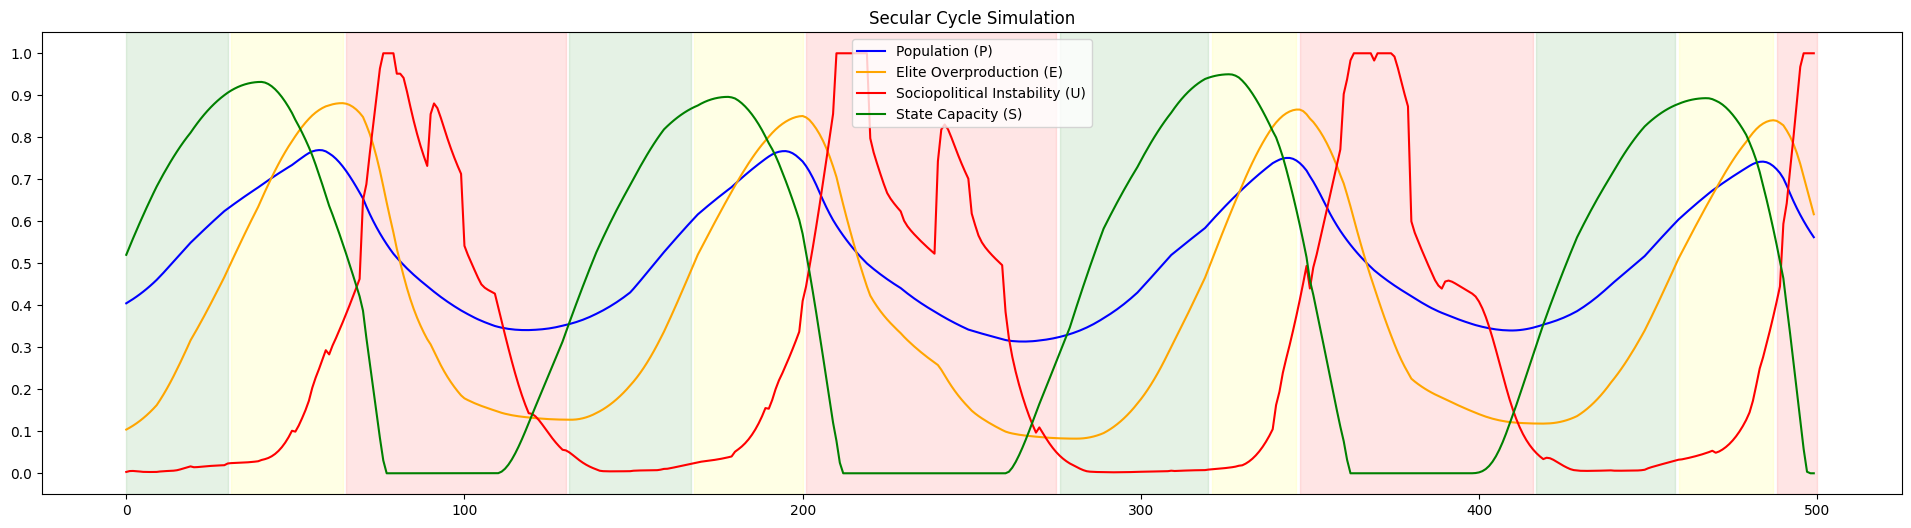

In [638]:
random.seed(42)

final_sim = FinalSim(
    P=0.4,
    E=0.1,
    S=0.5,
    dP_mult=1.0,
    dE_mult=1.0,
    dS_mult=2.0,
    dP_nmult=1.0,
    dE_nmult=1.0,
    dS_nmult=1.0
)
for t in range(500):
    final_sim.step(t, randomness=0.0)

plot_simulation(    
    final_sim.P_history, final_sim.E_history, final_sim.U_e_history, final_sim.S_history, final_sim.phase_history
)
plot_simulation(    
    simple_sim.P_history, simple_sim.E_history, simple_sim.U_e_history, simple_sim.S_history, simple_sim.phase_history
)

Birth Rate:  0.04
Death Rate:  0.026


Text(0.5, 0, 'Time Steps')

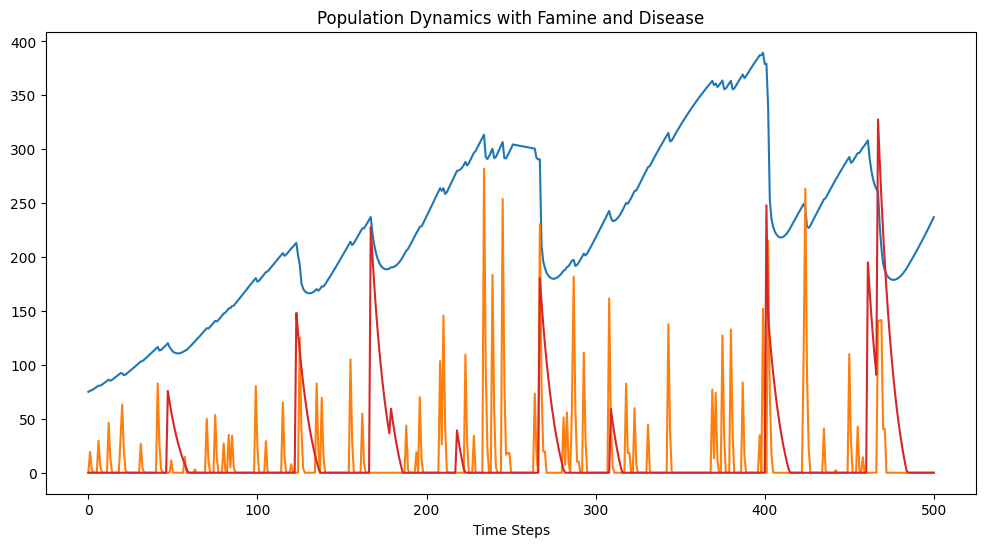

In [457]:
population = 75
carrying_cap = 100

random.seed(42)

birth_rate = final_sim.get_birth_rate(population, carrying_cap)
death_rate = final_sim.get_death_rate(population, carrying_cap, birth_rate, famine_severity=0.0, disease_severity=0.0)
print("Birth Rate: ", round(birth_rate, 4))
print("Death Rate: ", round(death_rate, 4))

famine_severity = 0.0
disease_severity = 0.0

pop_vals = [population]
famines_vals = [famine_severity]
disease_vals = [disease_severity]
for t in range(500):
    birth_rate = final_sim.get_birth_rate(population, carrying_cap, start_decline=0.75, end_decline=1.25)
    death_rate = final_sim.get_death_rate(population, carrying_cap, birth_rate, famine_severity, disease_severity)
    population = population + (birth_rate - death_rate) * population

    if random.random() < (population/carrying_cap) ** 2 * 0.03:  # Probability of disease outbreak increases with population pressure
        disease_severity += random.uniform(0.0, 1.0) ** 2
    else:
        disease_severity = max(0.0, disease_severity * 0.9 - 0.02)  # Disease severity decays over time

    if random.random() < 0.2:  # 20% chance of drought each step
        food_capacity = carrying_cap * random.uniform(0.5, 1.0)  # Drought reduces carrying capacity
        famine_severity += min(1.0, max(0.0, (population - food_capacity) / food_capacity))
    else:
        famine_severity = max(0.0, famine_severity * 0.4 - 0.05)  # Famine severity decays over time

    pop_vals.append(population)
    famines_vals.append(famine_severity * carrying_cap)  # Scale famine severity for plotting
    disease_vals.append(disease_severity * carrying_cap)

    carrying_cap += 1
    if t == 250:
        carrying_cap /= 1.5
    if t == 400:
        carrying_cap /= 1.5

plt.figure(figsize=(12, 6))
plt.plot(pop_vals, label="Population", color="tab:blue")
plt.plot(famines_vals, label="Famine Severity", color="tab:orange")
plt.plot(disease_vals, label="Disease Severity", color="tab:red")
plt.title("Population Dynamics with Famine and Disease")
plt.xlabel("Time Steps")